# Mobile phone model identification from audio recordings using deep learning and Multilinear Discriminant Analysis (MDA)
**L. Figes**
# Introduction 
This notebook implements a pipeline for CNN for deep learned features into Multilinear Discriminant Analysis (MDA) then final classification using a traditional classifier (RandomForest, SVM, LogisticRegression, k-NN, Naive Bayes, Decision Tree, LDA and MLP).

- This work uses an MDA implementation outlined in [1], using the code provided in: **https://github.com/tensorly/Proceedings_IEEE_companion_notebooks/blob/master/MDA.ipynb**.
- Uses dataset: POLIPHONE [2], which can be downloaded from: **https://zenodo.org/records/13903412**.

This notebook relies on six classes made for this work:
1. `CVFold` - Encapsulates a single cross-validation fold, enabling access to the train/validation/test splits of each fold in a class. Provides DataLoaders which use the SpectrogramDataset to convert raw spectrograms into PyTorch tensors for CNN training.
2. `SpectrogramDataset` - converts log-mel spectrograms in numpy arrays into PyTorch tensors adding the channel dimension for CNN input, implementing PyTorch dataset to enable PyTorch DataLoader compatability.
3. `ResNetCNN` - ResNet18 architecture modified to enable use as a feature extractor and for CNN-only classification.
4. `CNNTrainer` - Handles CNN training with mixed precision (to speed up training), learning rate scheduling, and early stopping based n validation loss. Encapsulates all training, evaluation and logging code for model training.
5. `FoldResults` - stores the trained model for each approach along with its accuracy.
6. `MultilinearDiscriminantAnalysis` - Implements a form of Tensor Discriminant Analysis, MDA for supervised dimensionality reduction by iteratively computing scatter matrices across tensor modes to maximise inter-class scatter and minimise intra-class scatter. Transforms high-dimensional spectrograms or CNN features into a lower subspace.

# Imports and Setup
This notebook was executed on the `pytorch/pytorch:2.3.0-cuda12.1-cudnn8-runtime` docker image and requires the following libraries:
1. pandas
2. numpy
3. scipy
4. matplotlib
5. seaborn
6. scikit-learn
7. librosa
8. tensorly
This step imports what is needed and ensures the GPU is available.

In [1]:
import numpy as np
import pandas as pd
import librosa
import os, re, random, copy
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from scipy import stats
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import contextmanager
from time import time
#custom classes
from MDA import MultilinearDiscriminantAnalysis
from ResNetCNN import ResNetCNN
from CNNTrainer import CNNTrainer
from CVFold import CVFold
from FoldResults import FoldResults
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060


# Timing Measurement
This step is needed to calculate the computational efficiency of each approach.

In [2]:
"""
timing to tell how long each approach takes, taken from https://medium.com/@DahlitzF/how-to-create-your-own-timing-context-manager-in-python-a0e944b48cf8
"""
timings = {}

@contextmanager
def timing(description, cond, fold):
    start = time()
    yield
    end = time()
    elapsed = end-start
    print(f"{description}: {end - start:.2f} seconds")
    timings[(cond, fold, description)] = elapsed

# Load POLIPHONE
Gather the files in POLIPHONE from all 4 conditions.

In [3]:
data_dir = "POLIPHONE/POLIPHONE/normalized_data_44k"
folder_names = ['speech_clean', 'speech_noise', 'music', 'esc10']
print(f"Loading from the folders: {folder_names}")
                  
    
all_poliphone = {
    'speech_clean': [],
    'speech_noise': [],
    'music': [],
    'esc10': []
}
   
for root, _, files in os.walk(data_dir):
    folder_name = os.path.basename(root)
        
    if folder_name in folder_names:
        phone_model = os.path.basename(os.path.dirname(root))
            
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                all_poliphone[folder_name].append((file_path, phone_model, folder_name))
    
total_files = sum(len(files) for files in all_poliphone.values())
print(f"Found {total_files} audio files")
    
for folder_type, files in all_poliphone.items():
    print(f"{folder_type}: {len(files)} files")

Loading from the folders: ['speech_clean', 'speech_noise', 'music', 'esc10']
Found 10480 audio files
speech_clean: 600 files
speech_noise: 600 files
music: 1280 files
esc10: 8000 files


# Windowing and Spectrogram Representation
Processes audio files from each condition into 1second log-mel spectrogram windows, limited to 450 samples per class to ensure balance. These are returned as a dictionary of numpy arrays with the spectrogram windows and corresponding labels and mappings and total classes for CNN training and use in MDA.

In [4]:
np.random.seed(2003)

def preprocess(condition_files, max_duration=15, window_duration=1, max_total_windows=9000, sr=44100):
    """
    Converts poliphone audio files into 1s temporal windows which are represented as mel spectrograms
    """
    windows_by_class = defaultdict(list)
    window_size = int(window_duration * sr)

    printed_dim = False
    
    for file_path, phone_model, _ in condition_files:
        audio = librosa.load(file_path, sr=sr)[0]
        audio = librosa.util.normalize(librosa.effects.trim(audio)[0])[:max_duration * sr]
            
        if len(audio) < window_size:
            print("skipping too short file")
            continue
                
        max_windows = min(15, len(audio) // window_size)
            
        for i in range(max_windows):
            start = i * window_size
            end = start + window_size
            window_audio = audio[start:end]
                    
            mel_db = librosa.power_to_db(
                librosa.feature.melspectrogram(
                    y=window_audio, sr=sr, n_fft=2048,
                    hop_length=512, n_mels=128, center=False
                ), ref=np.max
            )

            if not printed_dim:
                print(f"spectrogram shape: {mel_db.shape}")
                printed_dim = True
                        
            windows_by_class[phone_model].append((mel_db, file_path))
            
    all_windows, all_labels, final_tracking = [], [], []
    
    for phone_model, class_data in windows_by_class.items():
        for mel_db, file_path in class_data:
            all_windows.append(mel_db)
            all_labels.append(phone_model)
            final_tracking.append((file_path, phone_model))
    
    if max_total_windows and len(all_windows) > max_total_windows:
        print(f"{max_total_windows} windows from {len(all_windows)} total")
        
        # maintain class balance
        indices_by_class = defaultdict(list)
        for idx, label in enumerate(all_labels):
            indices_by_class[label].append(idx)
        
        sampled_indices = []
        classes = list(indices_by_class.keys())
        samples_per_class = max_total_windows // len(classes)
        remaining = max_total_windows % len(classes)
        
        for i, phone_model in enumerate(classes):
            class_indices = indices_by_class[phone_model]
            n_samples = samples_per_class + (1 if i < remaining else 0)
            n_samples = min(n_samples, len(class_indices))
            
            sampled = np.random.choice(class_indices, n_samples, replace=False)
            sampled_indices.extend(sampled)
        
        sampled_indices = np.array(sampled_indices)
        all_windows = [all_windows[i] for i in sampled_indices]
        all_labels = [all_labels[i] for i in sampled_indices]
        final_tracking = [final_tracking[i] for i in sampled_indices]
        
    classes = sorted(set(all_labels))
    label_map = {label: idx for idx, label in enumerate(classes)}
    
    print(f"Final dataset: {len(all_windows)} windows, {len(classes)} classes")
    print("Distribution:", {cls: all_labels.count(cls) for cls in classes})
    
    return {
        'windows': np.array(all_windows),
        'label_indices': np.array([label_map[label] for label in all_labels]),
        'label_map': label_map,
        'classes': classes,
        'file_tracking': final_tracking
    }

In [5]:
speech_clean_data = preprocess(all_poliphone['speech_clean'])
speech_noise_data = preprocess(all_poliphone['speech_noise'])
music_data = preprocess(all_poliphone['music'])
esc_data = preprocess(all_poliphone['esc10'])

spectrogram shape: (128, 83)
Final dataset: 9000 windows, 20 classes
Distribution: {'huawei_nova_9': 450, 'huawei_nova_9_se': 450, 'huawei_p30': 450, 'iphone_12_mini': 450, 'iphone_13': 450, 'iphone_xs_max': 450, 'moto_edge_20': 450, 'moto_edge_30': 450, 'moto_g9_power': 450, 'oneplus_nord': 450, 'poco_m4_pro': 450, 'poco_x4_pro': 450, 'realme_gt': 450, 'redmagic': 450, 'redmi_note_11': 450, 'rog_phone_3': 450, 'rog_phone_5': 450, 'xiaomi_12': 450, 'xiaomi_12_pro': 450, 'xiaomi_12_x': 450}
spectrogram shape: (128, 83)
Final dataset: 9000 windows, 20 classes
Distribution: {'huawei_nova_9': 450, 'huawei_nova_9_se': 450, 'huawei_p30': 450, 'iphone_12_mini': 450, 'iphone_13': 450, 'iphone_xs_max': 450, 'moto_edge_20': 450, 'moto_edge_30': 450, 'moto_g9_power': 450, 'oneplus_nord': 450, 'poco_m4_pro': 450, 'poco_x4_pro': 450, 'realme_gt': 450, 'redmagic': 450, 'redmi_note_11': 450, 'rog_phone_3': 450, 'rog_phone_5': 450, 'xiaomi_12': 450, 'xiaomi_12_pro': 450, 'xiaomi_12_x': 450}
spectrogra

# Mixed-Condition Creation
The mixed-condition is equal parts of each condition: speech_clean, speech_noise, music, esc10 (environmental sounds) data. It randomly downsamples the number of windows from each condition to create a balanced condition dataset.

In [6]:
def create_mixed_condition(speech_clean_data, speech_noise_data, music_data, esc_data, max_per_class=450):
    """
    Creates a mixed dataset by sampling equally from each condition for each phone model.
    """
    conditions = [speech_clean_data, speech_noise_data, music_data, esc_data]
    samples_per_condition = max_per_class // len(conditions)
    common_classes = sorted(speech_clean_data['classes'])
    
    print(f"Creating mixed condition: {samples_per_condition} samples from each of {len(conditions)} conditions")
    print(f"Total per class: {max_per_class}, Classes: {len(common_classes)}")
    
    all_windows, all_labels, all_tracking = [], [], []
    
    for phone_model in common_classes:
        for condition_data in conditions:
            phone_idx = condition_data['label_map'][phone_model]
            condition_indices = np.where(condition_data['label_indices'] == phone_idx)[0]
            
            sampled_indices = np.random.choice(
                condition_indices, 
                samples_per_condition, 
                replace=len(condition_indices) < samples_per_condition
            )
            
            all_windows.extend(condition_data['windows'][sampled_indices])
            all_labels.extend([phone_model] * samples_per_condition)
            all_tracking.extend([condition_data['file_tracking'][i] for i in sampled_indices])
    
    label_map = {label: idx for idx, label in enumerate(common_classes)}
    
    print(f"Final dataset: {len(all_windows)} windows, {len(common_classes)} classes")
    print("Distribution:", {cls: all_labels.count(cls) for cls in common_classes})
    
    return {
        'windows': np.array(all_windows),
        'label_indices': np.array([label_map[label] for label in all_labels]),
        'label_map': label_map,
        'classes': common_classes,
        'file_tracking': all_tracking
    }

mixed_data = create_mixed_condition(speech_clean_data, speech_noise_data, music_data, esc_data)

Creating mixed condition: 112 samples from each of 4 conditions
Total per class: 450, Classes: 20
Final dataset: 8960 windows, 20 classes
Distribution: {'huawei_nova_9': 448, 'huawei_nova_9_se': 448, 'huawei_p30': 448, 'iphone_12_mini': 448, 'iphone_13': 448, 'iphone_xs_max': 448, 'moto_edge_20': 448, 'moto_edge_30': 448, 'moto_g9_power': 448, 'oneplus_nord': 448, 'poco_m4_pro': 448, 'poco_x4_pro': 448, 'realme_gt': 448, 'redmagic': 448, 'redmi_note_11': 448, 'rog_phone_3': 448, 'rog_phone_5': 448, 'xiaomi_12': 448, 'xiaomi_12_pro': 448, 'xiaomi_12_x': 448}


# K-Fold Cross-Validation
Creates the cross-validation splits by normalising spectrogram data and splitting into train/val/test splits. This is done by splitting the total set into 80% train/val (7200 samples, 5760 train, 1440 test) with the remaining a 20% test set (1800). Resulting in an overall 64% train, 16% val and 20% test.

In [7]:
def make_cv_splits(windows, lbls, k_folds, file_tracking, batch_size=128, random_state=2003):
    """
    Makes stratified k-fold cross validation at the recording level
    """
    windows_normalised = (windows - np.mean(windows)) / np.std(windows)
    
    unique_files = list(set([ft[0] for ft in file_tracking]))
    file_to_label = {ft[0]: ft[1] for ft in file_tracking}
    file_labels = [file_to_label[f] for f in unique_files]

    print(f"Files per class: {Counter(file_labels)}")
    
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    fold_data = []

    print(f"Creating {k_folds} fold cross-validation splits")
    print(f"Total windows: {len(windows)}")
    
    for fold, (train_val_files_idx, test_files_idx) in enumerate(skf.split(unique_files, file_labels)):
        train_val_files = [unique_files[i] for i in train_val_files_idx]
        test_files = [unique_files[i] for i in test_files_idx]
        
        #window indices for each file set
        train_val_indices = [i for i, ft in enumerate(file_tracking) if ft[0] in train_val_files]
        test_indices = [i for i, ft in enumerate(file_tracking) if ft[0] in test_files]
        
        # Split train_val further at recording file level
        train_val_files_for_split = [file_tracking[i][0] for i in train_val_indices]
        train_val_labels_for_split = [lbls[i] for i in train_val_indices]
        
        unique_train_val_files = list(set(train_val_files_for_split))
        train_files, val_files = train_test_split(
            unique_train_val_files, test_size=0.2, random_state=random_state,
            stratify=[file_to_label[f] for f in unique_train_val_files]
        )
        
        train_indices = [i for i in train_val_indices if file_tracking[i][0] in train_files]
        val_indices = [i for i in train_val_indices if file_tracking[i][0] in val_files]
        
        print(f"Fold {fold + 1}")
        print(f"Train samples per class: {Counter(lbls[train_indices])}")
        print(f"Val samples per class: {Counter(lbls[val_indices])}")
        print(f"Test samples per class: {Counter(lbls[test_indices])}")
        
        fold_data.append(CVFold(
            fold + 1,
            windows_normalised[train_indices], lbls[train_indices],
            windows_normalised[val_indices], lbls[val_indices],
            windows_normalised[test_indices], lbls[test_indices],
        ))
    
    return fold_data

# Apply MDA
Apply MDA and get the optimal rank value for the validation set using 1-nearest neighbour classification. This is where this approach differs from the original GitHub implementation as it instead of using a fixed rank of `16`, this work tries: `4, 8 and 16`. It then applies this optimal MDA model to transform the training and testing data for later use.

In [8]:
def apply_mda(train_features, train_lbls, val_features, val_lbls, test_features=None):
    """
    Use validation set to select best rank, then apply to test set
    """
    test_ranks = [4, 8, 16]
    best_acc = 0
    best_rank = None
    mda_best = None
    
    for test_rank in test_ranks:
        mda = MultilinearDiscriminantAnalysis(rank=test_rank)
        mda_train = mda.fit_transform(train_features, train_lbls)
        mda_val = mda.transform(val_features)
        
        # 1 NN to validate best rank using validation set
        knn = KNeighborsClassifier(n_neighbors=1)
        knn.fit(mda_train, train_lbls)
        accuracy = knn.score(mda_val, val_lbls)
        
        if accuracy > best_acc:
            best_acc = accuracy
            best_rank = test_rank
            mda_best = mda
    
    # apply the best MDA to get final train/test features
    mda_train_final = mda_best.fit_transform(train_features, train_lbls)
    mda_test_final = mda_best.transform(test_features) if test_features is not None else None
    
    return mda_train_final, mda_test_final, best_rank, mda_best

# Confusion Matrix
Make confusion matrices and classification reports (which show precision, recall and F1 score by class) for showing the worst performing phone models by approach.

In [9]:
def generate_confusion_matrices(cnn_true, cnn_pred, cnn_mda_true, cnn_mda_pred, mda_only_true, mda_only_pred, fold_results, label_map, condition_name):
    class_names = [class_name for class_name, _ in sorted(label_map.items(), key=lambda x: x[1])]

    def get_best_classifier(fold_results, result_attr):
        """best mean classifier across folds"""
        all_scores = {}
        for fold_result in fold_results:
            for clf, score in getattr(fold_result, result_attr).items():
                all_scores.setdefault(clf, []).append(score)
        return max(all_scores.keys(), key=lambda clf: np.mean(all_scores[clf]))

    def f1_scores(y_true, y_pred, method_name):
        """F1 scores sorted from high-to-low"""
        f1_scores = f1_score(y_true, y_pred, labels=range(len(class_names)), average=None)
        device_f1_pairs = list(zip(class_names, f1_scores))
        device_f1_pairs.sort(key=lambda x: x[1], reverse=True)
        
        print(f"\nF1 Scores: {method_name}:")
        for i, (device, f1) in enumerate(device_f1_pairs, 1):
            print(f"{i:2d}. {device:<20} {f1:.4f}")
        
        print(f"\nTop 5:")
        for i, (device, f1) in enumerate(device_f1_pairs[:5], 1):
            print(f"{i}. {device}: {f1:.4f}")
        
        print(f"\nBottom 5:")
        for i, (device, f1) in enumerate(device_f1_pairs[-5:], 1):
            rank = len(device_f1_pairs) - 5 + i
            print(f"{rank}. {device}: {f1:.4f}")
    
    def plot_cm(y_true, y_pred, method_name):
        """confusion matrix, classification and summary table."""
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix: {method_name} - {condition_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        misclass_data = []
        for actual_idx, actual_class in enumerate(class_names):
            for pred_idx, pred_class in enumerate(class_names):
                if actual_idx != pred_idx and cm[actual_idx, pred_idx] > 0:
                    misclass_data.append({
                        'Actual': actual_class,
                        'Predicted': pred_class, 
                        'Count': cm[actual_idx, pred_idx]
                    })

        if misclass_data:
            misclass_df = pd.DataFrame(misclass_data)
            print(f"\nMisclassifications - {method_name}:")
            display(misclass_df)

        f1_scores(y_true, y_pred, method_name)

    plot_cm(cnn_true, cnn_pred, "CNN only")

    best_cnn_mda = get_best_classifier(fold_results, 'cnn_mda_results')
    plot_cm(cnn_mda_true, cnn_mda_pred[best_cnn_mda], f"CNN+MDA ({best_cnn_mda})")

    best_mda = get_best_classifier(fold_results, 'mda_only_results')
    plot_cm(mda_only_true, mda_only_pred[best_mda], f"MDA only ({best_mda})")

# Traditional Classifier Testing

In [10]:
def test_classifiers(train_data, train_lbls, test_data, test_lbls, method_name, classifiers):
    """
    test each of the classifiers on the MDA
    returns accuracy and predictions for each classifier for comparison later
    """
    results = {}
    predictions = {}
    
    for name, classifier_func in classifiers.items():
        classifier = classifier_func()
        classifier.fit(train_data, train_lbls)
        pred_lbls = classifier.predict(test_data)
        accuracy = accuracy_score(test_lbls, pred_lbls)
        results[name] = accuracy
        predictions[name] = pred_lbls
    
    return results, predictions

# Training and Evaluation
Train and evaluate the CNN-only, MDA-only and CNN+MDA hybrid using the k-fold cross validation splits. Collect the prediction and make the confusion matrices and return the results.

In [ ]:
def extend_predictions(trues, all_preds, extr_lbls, cur_preds):
    """
    helps with train_condition_model
    """
    trues.extend(extr_lbls)
    for clf, pred in cur_preds.items():
        if clf not in all_preds:
            all_preds[clf] = []
        all_preds[clf].extend(pred)

def mda_only(cv_fold, all_mda_only_true, all_mda_only_pred, on_cnn_extr=None):
    """
    for the MDA only pipeline, could be adapted to accept CNN features as input
    """
    mda_only_train, mda_only_test, best_rank, mda_raw_model = apply_mda(
        cv_fold.train_data, cv_fold.train_lbls, 
        cv_fold.val_data, cv_fold.val_lbls, 
        cv_fold.test_data
    )
    
    mda_only_results, mda_only_predictions = test_classifiers(
        mda_only_train, cv_fold.train_lbls, mda_only_test, cv_fold.test_lbls, "MDA only", classifiers
    )
    # collect MDA only predictions
    extend_predictions(all_mda_only_true, all_mda_only_pred, cv_fold.test_lbls, mda_only_predictions)
    return mda_only_results, mda_raw_model

def cnn_only(cv_fold, epochs, patience, early_stopping_patience, min_lr):
    """
    train the CNN model with the classifier for CNN only accuracy
    the model from this is later used with MDA but without the classifier
    """
    print(f"Unique labels in training: {np.unique(cv_fold.train_lbls)}")
    print(f"Training data shape: {cv_fold.train_data.shape}")
    
    n_classes = len(np.unique(cv_fold.train_lbls))
    
    cnn_model = ResNetCNN(n_classes=n_classes)
    
    train_loader = cv_fold.train_loader()
    val_loader = cv_fold.val_loader()
    test_loader = cv_fold.test_loader()
        
    trainer = CNNTrainer(lr=0.001, patience=patience, early_stopping_patience=early_stopping_patience, min_lr=min_lr)
    trained_model = trainer.train(cnn_model, train_loader, val_loader, epochs=epochs)
    
    test_accuracy, predictions, true_lbls = trainer.evaluate(test_loader)
    print(f"CNN only accuracy: {test_accuracy:.4f}")

    return trained_model, trainer, true_lbls, predictions, test_accuracy

def extract_features(model, dataloader):
    """
    get the features and labels from the CNN model and represent them as np arrays
    """
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for batch_data, batch_labels in dataloader:
            batch_data = batch_data.to(device)
            batch_features = model.get_features(batch_data)
            features.append(batch_features.cpu().numpy())
            labels.append(batch_labels.numpy())
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    return features, labels

def cnn_mda_combined(cv_fold, trained_cnn_model, classifiers):
    """
    Use pretrained CNN to extract features, then apply MDA, then test classifiers
    """
    print(f"CNN + MDA combined")
    
    # train test val features as Torch tensor data loaders
    train_loader = cv_fold.train_loader()
    val_loader = cv_fold.val_loader()
    test_loader = cv_fold.test_loader()
    
    # Get CNN features from all sets
    train_features, train_lbls = extract_features(trained_cnn_model, train_loader)
    val_features, val_lbls = extract_features(trained_cnn_model, val_loader)
    test_features, test_lbls = extract_features(trained_cnn_model, test_loader)
    
    print(f"CNN feature shapes - Train: {train_features.shape}, Val: {val_features.shape}, Test: {test_features.shape}")
    
    mda_train_features, mda_test_features, best_rank, mda_model = apply_mda(
        train_features, train_lbls,
        val_features, val_lbls,
        test_features
    )
    
    cnn_mda_results, cnn_mda_predictions = test_classifiers(
        mda_train_features, train_lbls, 
        mda_test_features, test_lbls,
        "CNN+MDA", classifiers
    )
    
    return cnn_mda_results, cnn_mda_predictions, test_lbls, mda_model


def train_condition_model(windows, label_indices, file_tracking, epochs, classifiers, label_map, condition_name, k_folds, patience, early_stopping_patience, min_lr):
    """
        Uses the CNN architecture designed for this project (3 conv layer with BN and ReLU activation)
        trains it using the given CV fold and evaluates its performance collecting
    """
    fold_data = make_cv_splits(windows, label_indices, k_folds=k_folds, file_tracking=file_tracking)
    
    all_cnn_true = []
    all_cnn_pred = []
    all_cnn_mda_true = []
    all_cnn_mda_pred = {}
    all_mda_only_true = []
    all_mda_only_pred = {}
    
    fold_results = []
    
    for cv_fold in fold_data:
        fold_num = cv_fold.fold
        print(f"\nTraining Models for fold {fold_num}/{k_folds}")
        # train a CNN model, use its classifier on the test set return the model and trainer for feature extraction + MDA
        fold_num = cv_fold.fold
        
        # CNN ONLY
        with timing(f"CNN training (fold {fold_num})", condition_name, fold_num):
            cnn_model, trainer, cnn_true_lbls, cnn_predictions, cnn_only_accuracy = cnn_only(cv_fold=cv_fold, epochs=epochs, patience=patience, early_stopping_patience=early_stopping_patience, min_lr=min_lr)
        # collect predictions
        all_cnn_true.extend(cnn_true_lbls)
        all_cnn_pred.extend(cnn_predictions)
        
        # MDA only
        with timing(f"MDA only training (fold {fold_num})", condition_name, fold_num):
            mda_only_results, mda_model = mda_only(cv_fold, all_mda_only_true, all_mda_only_pred)

        # CNN + MDA
        with timing(f"CNN+MDA training (fold {fold_num})", condition_name, fold_num):
            cnn_mda_results, cnn_mda_predictions, cnn_mda_true_lbls, cnn_trained_mda_model = cnn_mda_combined(cv_fold, cnn_model, classifiers)
        # collect CNN+MDA predictions
        extend_predictions(all_cnn_mda_true, all_cnn_mda_pred, cnn_mda_true_lbls, cnn_mda_predictions)
        
        print(f"\nFold {fold_num} results:")
        print(f"CNN only: {cnn_only_accuracy:.4f}")
        print(f"MDA only best: {max(mda_only_results.values()):.4f}")
        print(f"CNN+MDA best: {max(cnn_mda_results.values()):.4f}")

        fold_results.append(FoldResults(
            fold=fold_num,
            cnn_only_accuracy=cnn_only_accuracy,
            cnn_mda_results=cnn_mda_results,
            mda_only_results=mda_only_results,
            cnn_model=cnn_model,
            mda_model=mda_model,
            cnn_trained_mda_model=cnn_trained_mda_model,
            cv_fold=cv_fold
        ))
        
        # clear memory
        if device.type == 'cuda':
            torch.cuda.empty_cache()
    
    generate_confusion_matrices(
        all_cnn_true, all_cnn_pred,
        all_cnn_mda_true, all_cnn_mda_pred,
        all_mda_only_true, all_mda_only_pred,
        fold_results, label_map, condition_name
    )
    
    return fold_results

# Setup Condition Analysis
The following several cells do the above pipeline on the 5 conditions, applying 8 classifiers (plus k-NN with 4 different nearest neighbour configs) to the MDA-only features and the CNN+MDA features (important note is CNN-only uses the classifier trained with the CNN).

Files per class: Counter({'huawei_p30': 30, 'xiaomi_12': 30, 'oneplus_nord': 30, 'huawei_nova_9_se': 30, 'xiaomi_12_pro': 30, 'rog_phone_3': 30, 'xiaomi_12_x': 30, 'iphone_13': 30, 'iphone_12_mini': 30, 'realme_gt': 30, 'iphone_xs_max': 30, 'rog_phone_5': 30, 'moto_edge_30': 30, 'huawei_nova_9': 30, 'moto_edge_20': 30, 'moto_g9_power': 30, 'redmi_note_11': 30, 'poco_x4_pro': 30, 'redmagic': 30, 'poco_m4_pro': 30})
Creating 5 fold cross-validation splits
Total windows: 9000
Fold 1
Train samples per class: Counter({3: 300, 10: 300, 17: 300, 12: 300, 15: 285, 16: 285, 14: 285, 18: 285, 6: 285, 4: 285, 11: 285, 13: 285, 9: 285, 8: 285, 7: 285, 2: 285, 5: 285, 1: 285, 19: 285, 0: 285})
Val samples per class: Counter({15: 75, 16: 75, 14: 75, 18: 75, 6: 75, 4: 75, 11: 75, 13: 75, 9: 75, 8: 75, 7: 75, 2: 75, 5: 75, 1: 75, 19: 75, 0: 75, 3: 60, 10: 60, 17: 60, 12: 60})
Test samples per class: Counter({15: 90, 3: 90, 16: 90, 14: 90, 10: 90, 18: 90, 6: 90, 4: 90, 11: 90, 13: 90, 17: 90, 9: 90, 12

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Training for 35 epochs (early stopping: 8)
Results in format of loss/acc for both train and validation sets
Initial LR: 0.001000


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.2511/0.5915 | Val: 0.5365/0.8250 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1548/0.9481 | Val: 0.3452/0.9035 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0952/0.9688 | Val: 0.1049/0.9576 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0313/0.9915 | Val: 0.0575/0.9792 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0235/0.9927 | Val: 0.0883/0.9708 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0176/0.9957 | Val: 0.0481/0.9847 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0287/0.9929 | Val: 0.2058/0.9410 | LR: 0.001000
Epoch [15/35] | Train: 0.0057/0.9981 | Val: 0.0402/0.9889 | LR: 0.001000 - lowest loss so far
Epoch [16/35] | Train: 0.0036/0.9988 | Val: 0.0225/0.9910 | LR: 0.001000 - lowest loss so far
Epoch [18/35] | Train: 0.0014/0.9997 | Val: 0.0162/0.9965 | LR: 0.001000 - lowest loss so far
Epoch [20/35] | Train: 0.0354/0.9899 | Val: 0.1259/0.9660 | LR: 0.001000
Epoch [25/35] | Train: 0.0012

...

Epoch [ 1/35] | Train: 1.2149/0.6092 | Val: 0.5807/0.7861 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1693/0.9437 | Val: 0.2348/0.9125 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0560/0.9845 | Val: 0.1076/0.9604 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0701/0.9778 | Val: 0.1305/0.9569 | LR: 0.001000
Epoch [ 6/35] | Train: 0.0442/0.9863 | Val: 0.0745/0.9778 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0443/0.9854 | Val: 0.0690/0.9792 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0175/0.9943 | Val: 0.0547/0.9812 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.0035/0.9997 | Val: 0.0234/0.9924 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0009/1.0000 | Val: 0.0192/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [14/35] | Train: 0.0003/1.0000 | Val: 0.0186/0.9917 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0002/1.0000 | Val: 0.0180/0.9917 | LR: 0.001000 - lowest

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 1.2292/0.5939 | Val: 0.5311/0.7903 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.1001/0.9684 | Val: 0.1886/0.9472 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0508/0.9847 | Val: 0.0843/0.9729 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0225/0.9932 | Val: 0.0367/0.9889 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0689/0.9773 | Val: 0.0540/0.9785 | LR: 0.001000
Epoch [12/35] | Train: 0.0131/0.9969 | Val: 0.0323/0.9896 | LR: 0.001000 - lowest loss so far
Epoch [13/35] | Train: 0.0026/0.9993 | Val: 0.0235/0.9917 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0182/0.9943 | Val: 0.1210/0.9667 | LR: 0.001000
Epoch [20/35] | Train: 0.0024/0.9997 | Val: 0.0343/0.9896 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0235 at epoch 13
Restored model validation accuracy: 0.9917, validation loss: 0.0234
CNN only ac

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 1.3073/0.5712 | Val: 0.4784/0.8194 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1751/0.9415 | Val: 0.1663/0.9437 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0518/0.9854 | Val: 0.1907/0.9493 | LR: 0.001000
Epoch [ 6/35] | Train: 0.0182/0.9951 | Val: 0.0774/0.9743 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0056/0.9984 | Val: 0.0462/0.9847 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0108/0.9965 | Val: 0.0369/0.9847 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.0057/0.9988 | Val: 0.0345/0.9910 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0717/0.9818 | Val: 0.2296/0.9250 | LR: 0.001000
Epoch [15/35] | Train: 0.0086/0.9984 | Val: 0.0344/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [16/35] | Train: 0.0012/0.9997 | Val: 0.0253/0.9924 | LR: 0.001000 - lowest loss so far
Epoch [17/35] | Train: 0.0005/1.0000 | Val: 0.0237/0.9910 | LR: 0.001000 - lowest loss so far
Epoch [1

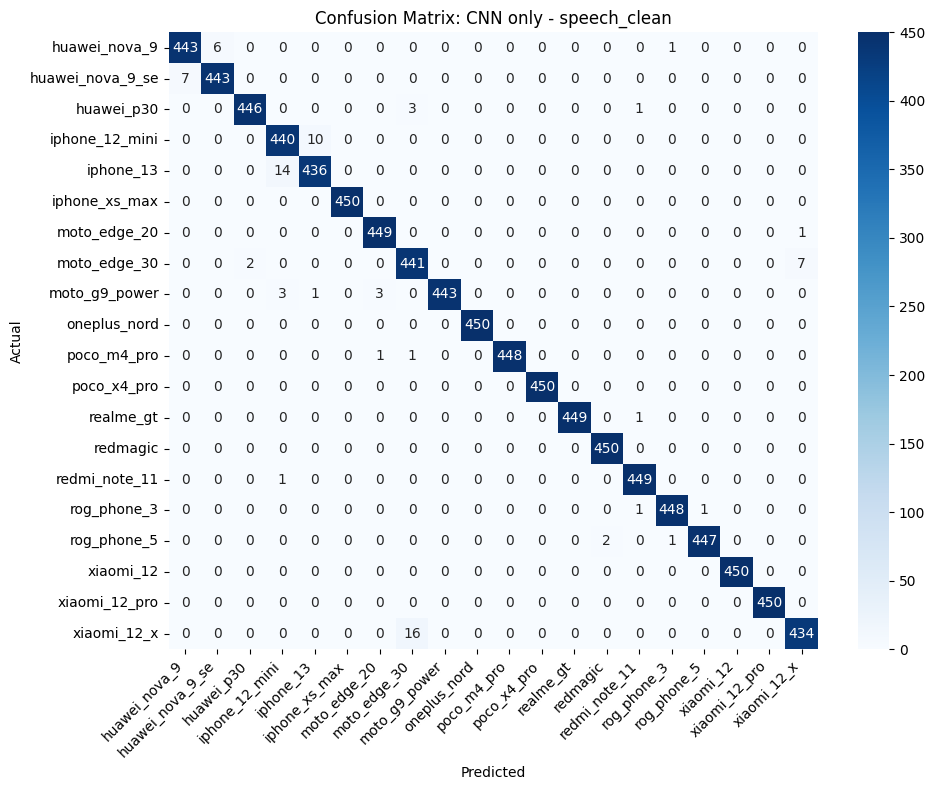


Misclassifications - CNN only:


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,6
1,huawei_nova_9,rog_phone_3,1
2,huawei_nova_9_se,huawei_nova_9,7
3,huawei_p30,moto_edge_30,3
4,huawei_p30,redmi_note_11,1
5,iphone_12_mini,iphone_13,10
6,iphone_13,iphone_12_mini,14
7,moto_edge_20,xiaomi_12_x,1
8,moto_edge_30,huawei_p30,2
9,moto_edge_30,xiaomi_12_x,7



F1 Scores: CNN only:
 1. iphone_xs_max        1.0000
 2. oneplus_nord         1.0000
 3. poco_x4_pro          1.0000
 4. xiaomi_12            1.0000
 5. xiaomi_12_pro        1.0000
 6. realme_gt            0.9989
 7. redmagic             0.9978
 8. poco_m4_pro          0.9978
 9. redmi_note_11        0.9956
10. rog_phone_3          0.9956
11. rog_phone_5          0.9955
12. moto_edge_20         0.9945
13. huawei_p30           0.9933
14. moto_g9_power        0.9922
15. huawei_nova_9_se     0.9855
16. huawei_nova_9        0.9844
17. xiaomi_12_x          0.9731
18. iphone_13            0.9721
19. iphone_12_mini       0.9692
20. moto_edge_30         0.9682

Top 5:
1. iphone_xs_max: 1.0000
2. oneplus_nord: 1.0000
3. poco_x4_pro: 1.0000
4. xiaomi_12: 1.0000
5. xiaomi_12_pro: 1.0000

Bottom 5:
16. huawei_nova_9: 0.9844
17. xiaomi_12_x: 0.9731
18. iphone_13: 0.9721
19. iphone_12_mini: 0.9692
20. moto_edge_30: 0.9682


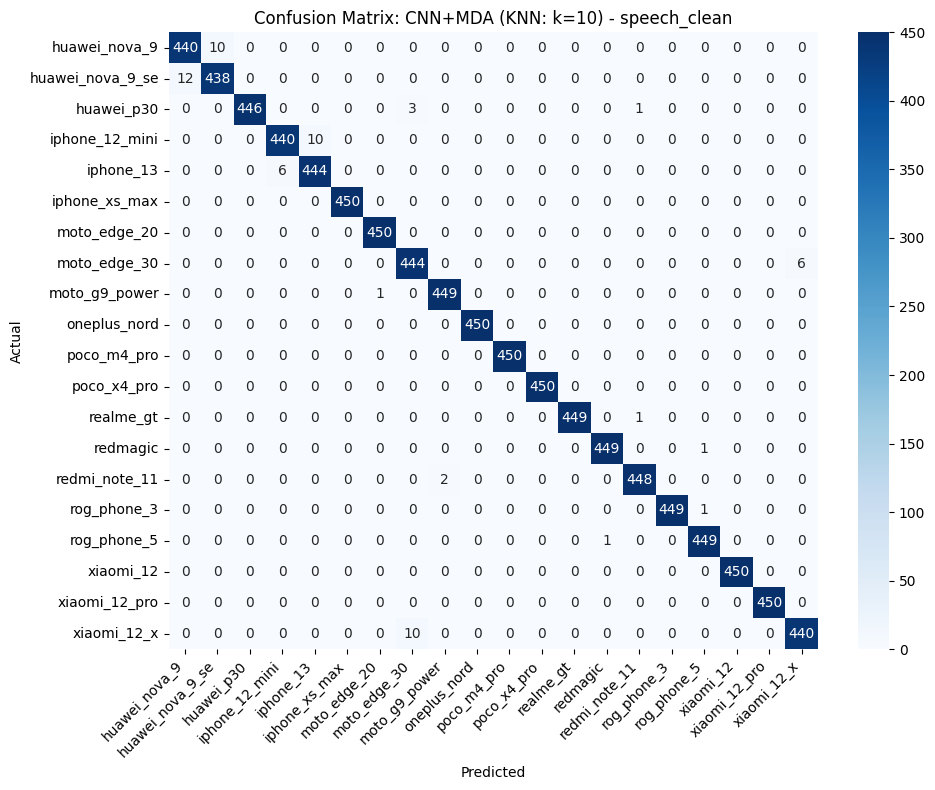


Misclassifications - CNN+MDA (KNN: k=10):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,10
1,huawei_nova_9_se,huawei_nova_9,12
2,huawei_p30,moto_edge_30,3
3,huawei_p30,redmi_note_11,1
4,iphone_12_mini,iphone_13,10
5,iphone_13,iphone_12_mini,6
6,moto_edge_30,xiaomi_12_x,6
7,moto_g9_power,moto_edge_20,1
8,realme_gt,redmi_note_11,1
9,redmagic,rog_phone_5,1



F1 Scores: CNN+MDA (KNN: k=10):
 1. iphone_xs_max        1.0000
 2. oneplus_nord         1.0000
 3. poco_m4_pro          1.0000
 4. poco_x4_pro          1.0000
 5. xiaomi_12            1.0000
 6. xiaomi_12_pro        1.0000
 7. moto_edge_20         0.9989
 8. realme_gt            0.9989
 9. rog_phone_3          0.9989
10. redmagic             0.9978
11. moto_g9_power        0.9967
12. rog_phone_5          0.9967
13. redmi_note_11        0.9956
14. huawei_p30           0.9955
15. iphone_13            0.9823
16. iphone_12_mini       0.9821
17. xiaomi_12_x          0.9821
18. moto_edge_30         0.9791
19. huawei_nova_9        0.9756
20. huawei_nova_9_se     0.9755

Top 5:
1. iphone_xs_max: 1.0000
2. oneplus_nord: 1.0000
3. poco_m4_pro: 1.0000
4. poco_x4_pro: 1.0000
5. xiaomi_12: 1.0000

Bottom 5:
16. iphone_12_mini: 0.9821
17. xiaomi_12_x: 0.9821
18. moto_edge_30: 0.9791
19. huawei_nova_9: 0.9756
20. huawei_nova_9_se: 0.9755


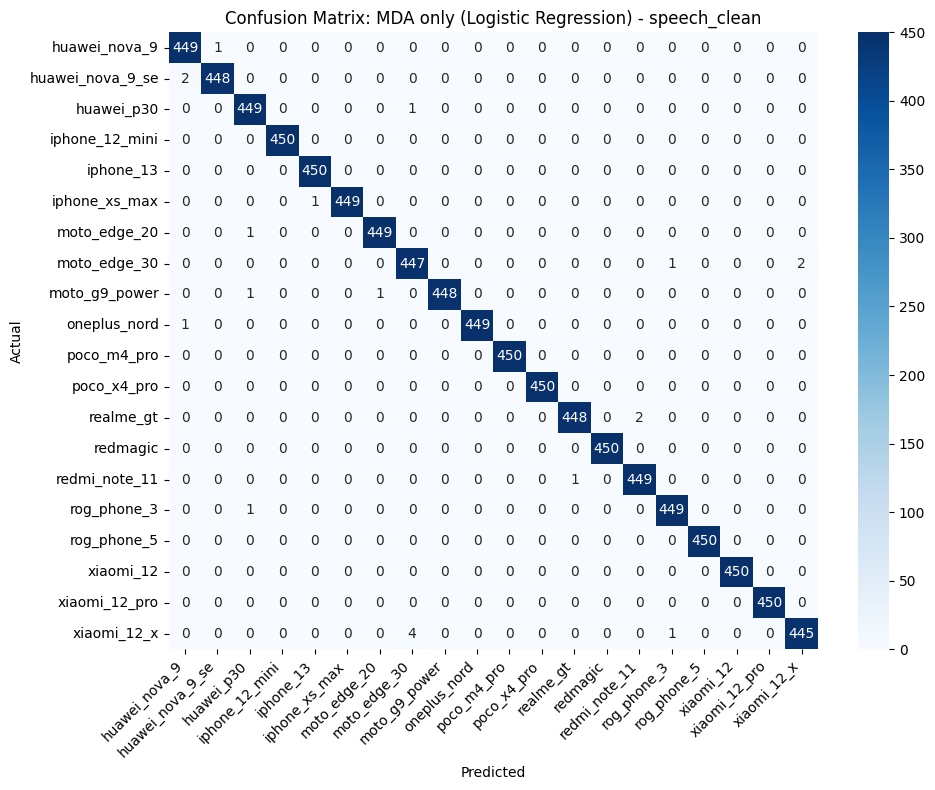


Misclassifications - MDA only (Logistic Regression):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,1
1,huawei_nova_9_se,huawei_nova_9,2
2,huawei_p30,moto_edge_30,1
3,iphone_xs_max,iphone_13,1
4,moto_edge_20,huawei_p30,1
5,moto_edge_30,rog_phone_3,1
6,moto_edge_30,xiaomi_12_x,2
7,moto_g9_power,huawei_p30,1
8,moto_g9_power,moto_edge_20,1
9,oneplus_nord,huawei_nova_9,1



F1 Scores: MDA only (Logistic Regression):
 1. iphone_12_mini       1.0000
 2. poco_m4_pro          1.0000
 3. poco_x4_pro          1.0000
 4. redmagic             1.0000
 5. rog_phone_5          1.0000
 6. xiaomi_12            1.0000
 7. xiaomi_12_pro        1.0000
 8. iphone_13            0.9989
 9. iphone_xs_max        0.9989
10. oneplus_nord         0.9989
11. moto_edge_20         0.9978
12. moto_g9_power        0.9978
13. redmi_note_11        0.9967
14. rog_phone_3          0.9967
15. huawei_nova_9_se     0.9967
16. realme_gt            0.9967
17. huawei_nova_9        0.9956
18. huawei_p30           0.9956
19. xiaomi_12_x          0.9922
20. moto_edge_30         0.9911

Top 5:
1. iphone_12_mini: 1.0000
2. poco_m4_pro: 1.0000
3. poco_x4_pro: 1.0000
4. redmagic: 1.0000
5. rog_phone_5: 1.0000

Bottom 5:
16. realme_gt: 0.9967
17. huawei_nova_9: 0.9956
18. huawei_p30: 0.9956
19. xiaomi_12_x: 0.9922
20. moto_edge_30: 0.9911


In [12]:
epochs=35
k_folds=5
patience=7
early_stopping_patience=8
min_lr=1e-5

# use lambda cos it ensures fresh classifier
classifiers = {
    'Random Forest': lambda: RandomForestClassifier(n_estimators=100, random_state=2003),
    'SVM': lambda: SVC(kernel='rbf', random_state=2003),
    'Logistic Regression': lambda: LogisticRegression(random_state=2003, max_iter=1000),
    'KNN: k=10': lambda: KNeighborsClassifier(n_neighbors=10),
    'KNN: k=5': lambda: KNeighborsClassifier(n_neighbors=5),
    'KNN: k=3': lambda: KNeighborsClassifier(n_neighbors=3),
    'KNN: k=1': lambda: KNeighborsClassifier(n_neighbors=1),
    'Naive Bayes': lambda: GaussianNB(),
    'Decision Tree': lambda: DecisionTreeClassifier(random_state=2003),
    'Linear Discriminant Analysis': lambda: LinearDiscriminantAnalysis(),
    'MLP': lambda: MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=2003)
}

speech_clean_kfold_results = train_condition_model(
    speech_clean_data['windows'],
    speech_clean_data['label_indices'],
    speech_clean_data['file_tracking'], 
    epochs=epochs,
    classifiers=classifiers,
    label_map=speech_clean_data['label_map'],
    condition_name="speech_clean",
    k_folds=k_folds,
    patience=patience,
    early_stopping_patience=early_stopping_patience,
    min_lr=min_lr
)

Files per class: Counter({'poco_m4_pro': 30, 'moto_edge_30': 30, 'xiaomi_12_x': 30, 'redmagic': 30, 'iphone_xs_max': 30, 'realme_gt': 30, 'huawei_nova_9_se': 30, 'xiaomi_12': 30, 'iphone_13': 30, 'rog_phone_5': 30, 'redmi_note_11': 30, 'oneplus_nord': 30, 'moto_edge_20': 30, 'huawei_p30': 30, 'poco_x4_pro': 30, 'xiaomi_12_pro': 30, 'moto_g9_power': 30, 'huawei_nova_9': 30, 'iphone_12_mini': 30, 'rog_phone_3': 30})
Creating 5 fold cross-validation splits
Total windows: 9000
Fold 1
Train samples per class: Counter({3: 300, 10: 300, 17: 300, 12: 300, 15: 285, 16: 285, 14: 285, 18: 285, 6: 285, 4: 285, 11: 285, 13: 285, 9: 285, 8: 285, 7: 285, 2: 285, 5: 285, 1: 285, 19: 285, 0: 285})
Val samples per class: Counter({15: 75, 16: 75, 14: 75, 18: 75, 6: 75, 4: 75, 11: 75, 13: 75, 9: 75, 8: 75, 7: 75, 2: 75, 5: 75, 1: 75, 19: 75, 0: 75, 3: 60, 10: 60, 17: 60, 12: 60})
Test samples per class: Counter({15: 90, 3: 90, 16: 90, 14: 90, 10: 90, 18: 90, 6: 90, 4: 90, 11: 90, 13: 90, 17: 90, 9: 90, 12

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 0.6983/0.7946 | Val: 0.1195/0.9653 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.0286/0.9917 | Val: 0.0216/0.9924 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0115/0.9972 | Val: 0.0134/0.9951 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0024/0.9997 | Val: 0.0099/0.9958 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0005/1.0000 | Val: 0.0093/0.9965 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0003/1.0000 | Val: 0.0074/0.9965 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0001/1.0000 | Val: 0.0085/0.9965 | LR: 0.001000
Epoch [11/35] | Train: 0.0001/1.0000 | Val: 0.0073/0.9965 | LR: 0.001000 - lowest loss so far
Epoch [12/35] | Train: 0.0001/1.0000 | Val: 0.0063/0.9979 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0001/1.0000 | Val: 0.0085/0.9965 | LR: 0.001000
Epoch [20/35] | Train: 0.0001/1.0000 | Val: 0.0075/0.9979 | LR: 0.000500
LR reduced: 0.001000 → 0.0005

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 0.6345/0.8049 | Val: 0.4017/0.8556 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.0247/0.9934 | Val: 0.1536/0.9514 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0144/0.9962 | Val: 0.1137/0.9653 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0198/0.9950 | Val: 0.0561/0.9868 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0013/1.0000 | Val: 0.0533/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0002/1.0000 | Val: 0.0483/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0001/1.0000 | Val: 0.0521/0.9910 | LR: 0.001000
Epoch [15/35] | Train: 0.0001/1.0000 | Val: 0.0515/0.9917 | LR: 0.000500
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0483 at epoch 7
Restored model validation accuracy: 0.9903, validation loss: 0.0490
CNN only accuracy: 0.9900
CNN training (fold 2): 22.07 seconds
MDA only training (fol

...

Epoch [ 1/35] | Train: 0.6471/0.8113 | Val: 0.2192/0.9667 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0340/0.9887 | Val: 0.1301/0.9764 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0050/0.9990 | Val: 0.1315/0.9674 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0015/0.9997 | Val: 0.1277/0.9778 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.0002/1.0000 | Val: 0.1218/0.9806 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0002/1.0000 | Val: 0.1372/0.9806 | LR: 0.001000
Epoch [12/35] | Train: 0.0001/1.0000 | Val: 0.1215/0.9806 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0001/1.0000 | Val: 0.1473/0.9806 | LR: 0.001000
Epoch [20/35] | Train: 0.0001/1.0000 | Val: 0.1378/0.9799 | LR: 0.000500
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.1215 at epoch 12
Restored model validation accuracy: 0.9806, validation loss: 0.1214
CNN only accuracy: 0.9989
CNN tr

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 0.6726/0.8045 | Val: 0.1651/0.9694 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.0133/0.9967 | Val: 0.1351/0.9681 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0331/0.9905 | Val: 0.0742/0.9771 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0084/0.9979 | Val: 0.0655/0.9792 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0099/0.9967 | Val: 0.1275/0.9694 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0086/0.9981 | Val: 0.0357/0.9840 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0002/1.0000 | Val: 0.0524/0.9812 | LR: 0.001000
Epoch [15/35] | Train: 0.0001/1.0000 | Val: 0.0614/0.9806 | LR: 0.000500
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0357 at epoch 7
Restored model validation accuracy: 0.9840, validation loss: 0.0357
CNN only accuracy: 1.0000
CNN training (fold 4): 21.99 seconds
MDA only training (fold 4): 17.74 seconds
C

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [ 1/35] | Train: 0.6680/0.8007 | Val: 0.0303/0.9910 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.0232/0.9938 | Val: 0.0235/0.9938 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0099/0.9974 | Val: 0.0060/0.9986 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0013/1.0000 | Val: 0.0034/0.9986 | LR: 0.001000 - lowest loss so far
Epoch [ 6/35] | Train: 0.0004/1.0000 | Val: 0.0010/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0003/1.0000 | Val: 0.0009/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0001/1.0000 | Val: 0.0008/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [11/35] | Train: 0.0001/1.0000 | Val: 0.0008/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [12/35] | Train: 0.0001/1.0000 | Val: 0.0007/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [13/35] | Train: 0.0001/1.0000 | Val: 0.0006/1.0000 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0001/1.0000 | Val: 0.0008/1.0000 | 

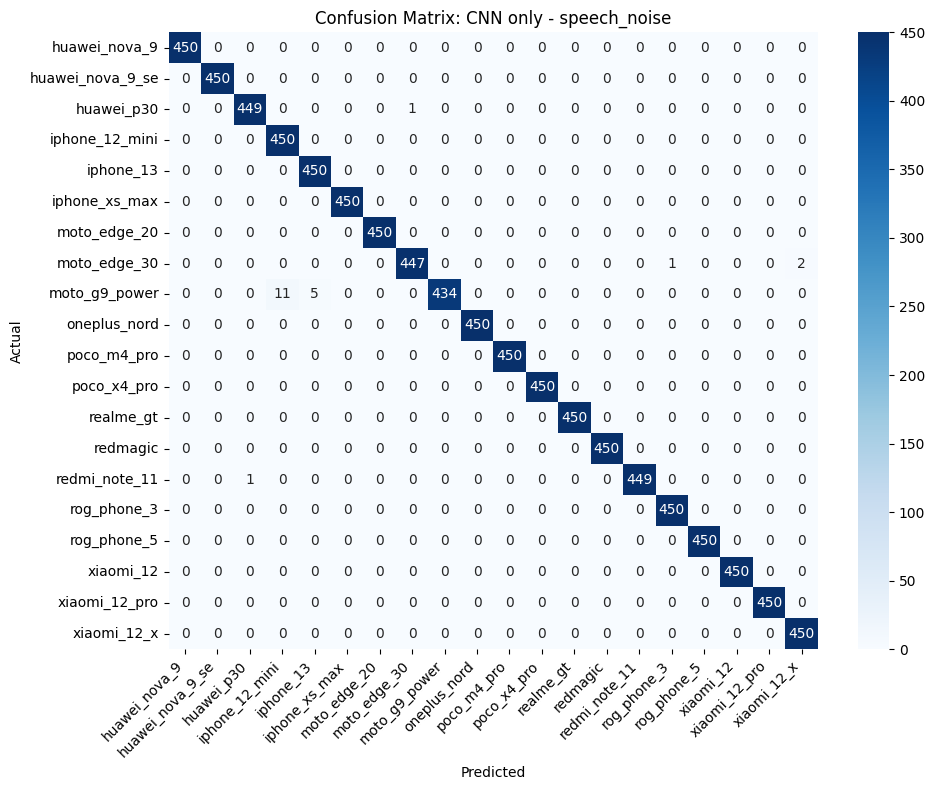


Misclassifications - CNN only:


,Actual,Predicted,Count
0,huawei_p30,moto_edge_30,1
1,moto_edge_30,rog_phone_3,1
2,moto_edge_30,xiaomi_12_x,2
3,moto_g9_power,iphone_12_mini,11
4,moto_g9_power,iphone_13,5
5,redmi_note_11,huawei_p30,1



F1 Scores: CNN only:
 1. huawei_nova_9        1.0000
 2. huawei_nova_9_se     1.0000
 3. iphone_xs_max        1.0000
 4. moto_edge_20         1.0000
 5. oneplus_nord         1.0000
 6. poco_m4_pro          1.0000
 7. poco_x4_pro          1.0000
 8. realme_gt            1.0000
 9. redmagic             1.0000
10. rog_phone_5          1.0000
11. xiaomi_12            1.0000
12. xiaomi_12_pro        1.0000
13. rog_phone_3          0.9989
14. redmi_note_11        0.9989
15. xiaomi_12_x          0.9978
16. huawei_p30           0.9978
17. moto_edge_30         0.9955
18. iphone_13            0.9945
19. iphone_12_mini       0.9879
20. moto_g9_power        0.9819

Top 5:
1. huawei_nova_9: 1.0000
2. huawei_nova_9_se: 1.0000
3. iphone_xs_max: 1.0000
4. moto_edge_20: 1.0000
5. oneplus_nord: 1.0000

Bottom 5:
16. huawei_p30: 0.9978
17. moto_edge_30: 0.9955
18. iphone_13: 0.9945
19. iphone_12_mini: 0.9879
20. moto_g9_power: 0.9819


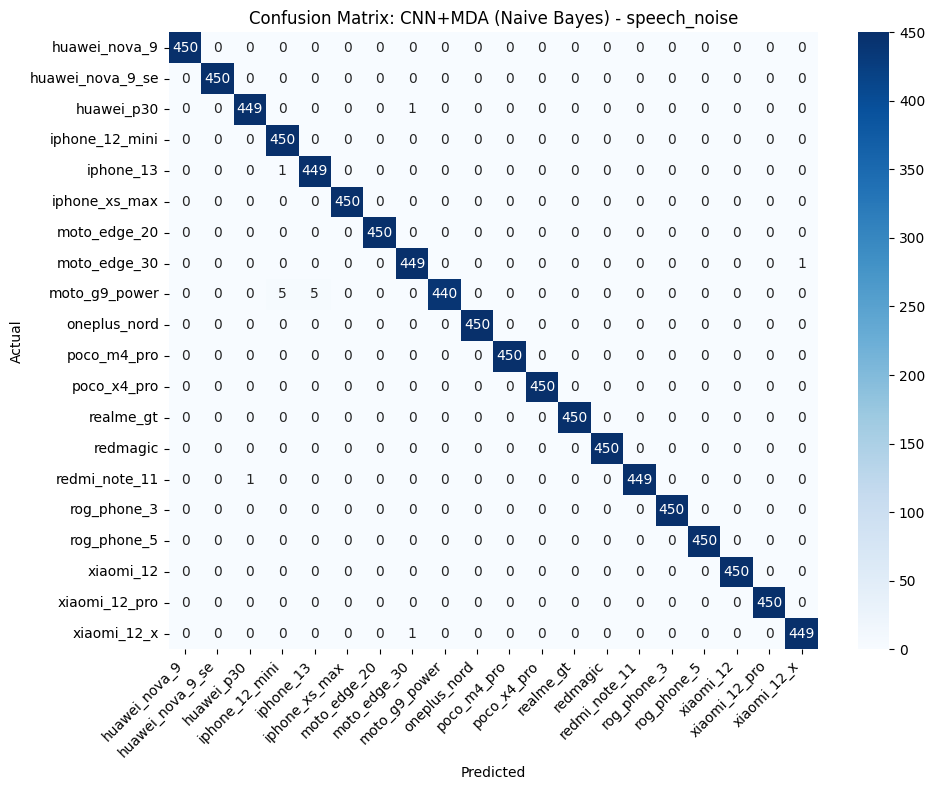


Misclassifications - CNN+MDA (Naive Bayes):


,Actual,Predicted,Count
0,huawei_p30,moto_edge_30,1
1,iphone_13,iphone_12_mini,1
2,moto_edge_30,xiaomi_12_x,1
3,moto_g9_power,iphone_12_mini,5
4,moto_g9_power,iphone_13,5
5,redmi_note_11,huawei_p30,1
6,xiaomi_12_x,moto_edge_30,1



F1 Scores: CNN+MDA (Naive Bayes):
 1. huawei_nova_9        1.0000
 2. huawei_nova_9_se     1.0000
 3. iphone_xs_max        1.0000
 4. moto_edge_20         1.0000
 5. oneplus_nord         1.0000
 6. poco_m4_pro          1.0000
 7. poco_x4_pro          1.0000
 8. realme_gt            1.0000
 9. redmagic             1.0000
10. rog_phone_3          1.0000
11. rog_phone_5          1.0000
12. xiaomi_12            1.0000
13. xiaomi_12_pro        1.0000
14. redmi_note_11        0.9989
15. huawei_p30           0.9978
16. xiaomi_12_x          0.9978
17. moto_edge_30         0.9967
18. iphone_12_mini       0.9934
19. iphone_13            0.9934
20. moto_g9_power        0.9888

Top 5:
1. huawei_nova_9: 1.0000
2. huawei_nova_9_se: 1.0000
3. iphone_xs_max: 1.0000
4. moto_edge_20: 1.0000
5. oneplus_nord: 1.0000

Bottom 5:
16. xiaomi_12_x: 0.9978
17. moto_edge_30: 0.9967
18. iphone_12_mini: 0.9934
19. iphone_13: 0.9934
20. moto_g9_power: 0.9888


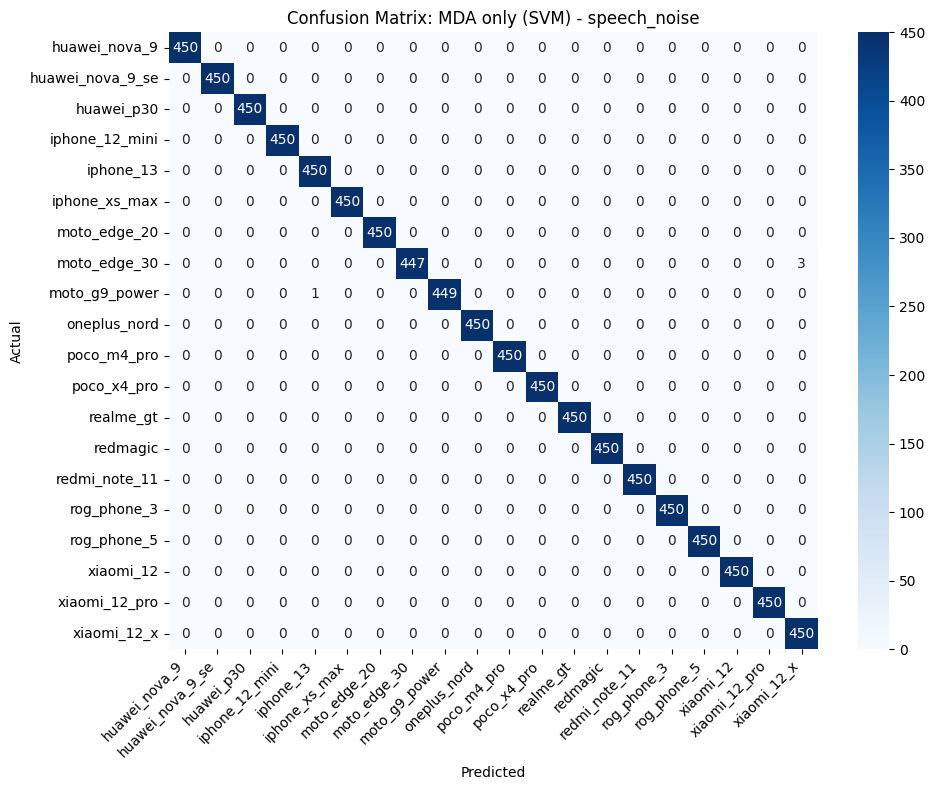


Misclassifications - MDA only (SVM):


,Actual,Predicted,Count
0,moto_edge_30,xiaomi_12_x,3
1,moto_g9_power,iphone_13,1



F1 Scores: MDA only (SVM):
 1. huawei_nova_9        1.0000
 2. huawei_nova_9_se     1.0000
 3. huawei_p30           1.0000
 4. iphone_12_mini       1.0000
 5. iphone_xs_max        1.0000
 6. moto_edge_20         1.0000
 7. oneplus_nord         1.0000
 8. poco_m4_pro          1.0000
 9. poco_x4_pro          1.0000
10. realme_gt            1.0000
11. redmagic             1.0000
12. redmi_note_11        1.0000
13. rog_phone_3          1.0000
14. rog_phone_5          1.0000
15. xiaomi_12            1.0000
16. xiaomi_12_pro        1.0000
17. iphone_13            0.9989
18. moto_g9_power        0.9989
19. xiaomi_12_x          0.9967
20. moto_edge_30         0.9967

Top 5:
1. huawei_nova_9: 1.0000
2. huawei_nova_9_se: 1.0000
3. huawei_p30: 1.0000
4. iphone_12_mini: 1.0000
5. iphone_xs_max: 1.0000

Bottom 5:
16. xiaomi_12_pro: 1.0000
17. iphone_13: 0.9989
18. moto_g9_power: 0.9989
19. xiaomi_12_x: 0.9967
20. moto_edge_30: 0.9967


In [13]:
speech_noise_kfold_results = train_condition_model(
    speech_noise_data['windows'], 
    speech_noise_data['label_indices'],
    speech_noise_data['file_tracking'],
    epochs=epochs,
    classifiers=classifiers,
    label_map=speech_noise_data['label_map'],
    condition_name="speech_noise",
    k_folds=k_folds,
    patience=patience,
    early_stopping_patience=early_stopping_patience,
    min_lr=min_lr
)

Files per class: Counter({'moto_g9_power': 64, 'poco_m4_pro': 64, 'xiaomi_12_pro': 64, 'redmagic': 64, 'huawei_nova_9_se': 64, 'oneplus_nord': 64, 'redmi_note_11': 64, 'huawei_nova_9': 64, 'rog_phone_5': 64, 'xiaomi_12': 64, 'huawei_p30': 64, 'moto_edge_20': 64, 'xiaomi_12_x': 64, 'iphone_xs_max': 64, 'realme_gt': 64, 'iphone_13': 64, 'moto_edge_30': 64, 'iphone_12_mini': 64, 'rog_phone_3': 64, 'poco_x4_pro': 64})
Creating 5 fold cross-validation splits
Total windows: 9000
Fold 1
Train samples per class: Counter({17: 307, 15: 302, 4: 302, 3: 301, 18: 298, 5: 296, 7: 295, 10: 293, 12: 293, 16: 291, 1: 291, 11: 289, 19: 288, 13: 287, 2: 282, 8: 281, 9: 280, 6: 276, 0: 276, 14: 273})
Val samples per class: Counter({12: 81, 1: 79, 19: 79, 6: 78, 11: 77, 8: 76, 14: 75, 9: 75, 17: 73, 18: 72, 2: 72, 16: 71, 5: 71, 0: 71, 13: 69, 10: 68, 15: 67, 7: 67, 4: 62, 3: 59})
Test samples per class: Counter({0: 103, 14: 102, 6: 96, 2: 96, 9: 95, 13: 94, 8: 93, 3: 90, 10: 89, 16: 88, 7: 88, 4: 86, 11: 

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 0.7450/0.7587 | Val: 0.3414/0.8918 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1012/0.9662 | Val: 0.1763/0.9431 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0405/0.9869 | Val: 0.0795/0.9757 | LR: 0.001000 - lowest loss so far
Epoch [ 6/35] | Train: 0.0312/0.9883 | Val: 0.0437/0.9868 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0212/0.9924 | Val: 0.0286/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0254/0.9924 | Val: 0.0696/0.9778 | LR: 0.001000
Epoch [11/35] | Train: 0.0113/0.9972 | Val: 0.0272/0.9917 | LR: 0.001000 - lowest loss so far
Epoch [12/35] | Train: 0.0055/0.9983 | Val: 0.0220/0.9931 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0156/0.9955 | Val: 0.1235/0.9619 | LR: 0.001000
Epoch [20/35] | Train: 0.0141/0.9953 | Val: 0.0385/0.9861 | LR: 0.000500
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.02

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 0.7502/0.7573 | Val: 0.2242/0.9290 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1226/0.9630 | Val: 0.1715/0.9414 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0756/0.9762 | Val: 0.0661/0.9793 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0295/0.9903 | Val: 0.2019/0.9317 | LR: 0.001000
Epoch [10/35] | Train: 0.0109/0.9971 | Val: 0.0323/0.9903 | LR: 0.001000 - lowest loss so far
Epoch [13/35] | Train: 0.0030/0.9991 | Val: 0.0168/0.9924 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0119/0.9971 | Val: 0.3651/0.9248 | LR: 0.001000
Epoch [20/35] | Train: 0.0203/0.9938 | Val: 0.1090/0.9669 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0168 at epoch 13
Restored model validation accuracy: 0.9924, validation loss: 0.0198
CNN only accuracy: 0.9903
CNN training (fold 2): 30.79 seconds
MDA only training (fold 2): 20.81 seconds


...

Epoch [ 1/35] | Train: 0.6949/0.7802 | Val: 0.6875/0.7792 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.1026/0.9657 | Val: 0.1177/0.9614 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0548/0.9815 | Val: 0.0666/0.9786 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0392/0.9876 | Val: 0.1481/0.9524 | LR: 0.001000
Epoch [10/35] | Train: 0.0234/0.9925 | Val: 0.0729/0.9717 | LR: 0.001000
Epoch [11/35] | Train: 0.0145/0.9946 | Val: 0.0536/0.9821 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0245/0.9911 | Val: 0.0536/0.9834 | LR: 0.001000 - lowest loss so far
Epoch [16/35] | Train: 0.0152/0.9942 | Val: 0.0374/0.9855 | LR: 0.001000 - lowest loss so far
Epoch [19/35] | Train: 0.0013/0.9997 | Val: 0.0251/0.9917 | LR: 0.001000 - lowest loss so far
Epoch [20/35] | Train: 0.0012/0.9998 | Val: 0.1200/0.9724 | LR: 0.001000
Epoch [21/35] | Train: 0.0009/0.9997 | Val: 0.0204/0.9945 | LR: 0.001000 - lowest loss so far
Epoch [25/35] | Train: 0.0001

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 0.7322/0.7609 | Val: 0.5455/0.8619 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0695/0.9786 | Val: 0.2119/0.9393 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0454/0.9869 | Val: 0.1426/0.9623 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0341/0.9908 | Val: 0.1578/0.9456 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0418/0.9869 | Val: 0.1299/0.9582 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0139/0.9953 | Val: 0.0366/0.9868 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0127/0.9960 | Val: 0.0736/0.9777 | LR: 0.001000
Epoch [15/35] | Train: 0.0232/0.9929 | Val: 0.1001/0.9770 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0366 at epoch 8
Restored model validation accuracy: 0.9868, validation loss: 0.0366
CNN only accuracy: 0.9852
CNN training (fold 4): 23.46 seconds
MDA only training (fold 4): 20.72 seconds
C

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 0.6977/0.7792 | Val: 0.2515/0.9163 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.0673/0.9788 | Val: 0.1651/0.9388 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.0389/0.9877 | Val: 0.1325/0.9592 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0304/0.9911 | Val: 0.0600/0.9782 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0231/0.9930 | Val: 0.1539/0.9578 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.0600 at epoch 5
Restored model validation accuracy: 0.9782, validation loss: 0.0641
CNN only accuracy: 0.9776
CNN training (fold 5): 19.24 seconds
MDA only training (fold 5): 20.61 seconds
CNN + MDA combined
CNN feature shapes - Train: (5752, 512), Val: (1421, 512), Test: (1827, 512)
CNN+MDA training (fold 5): 9.70 seconds

Fold 5 results:
CNN only: 0.9776
MDA only best: 0.9973
CNN+MDA best: 0.9918


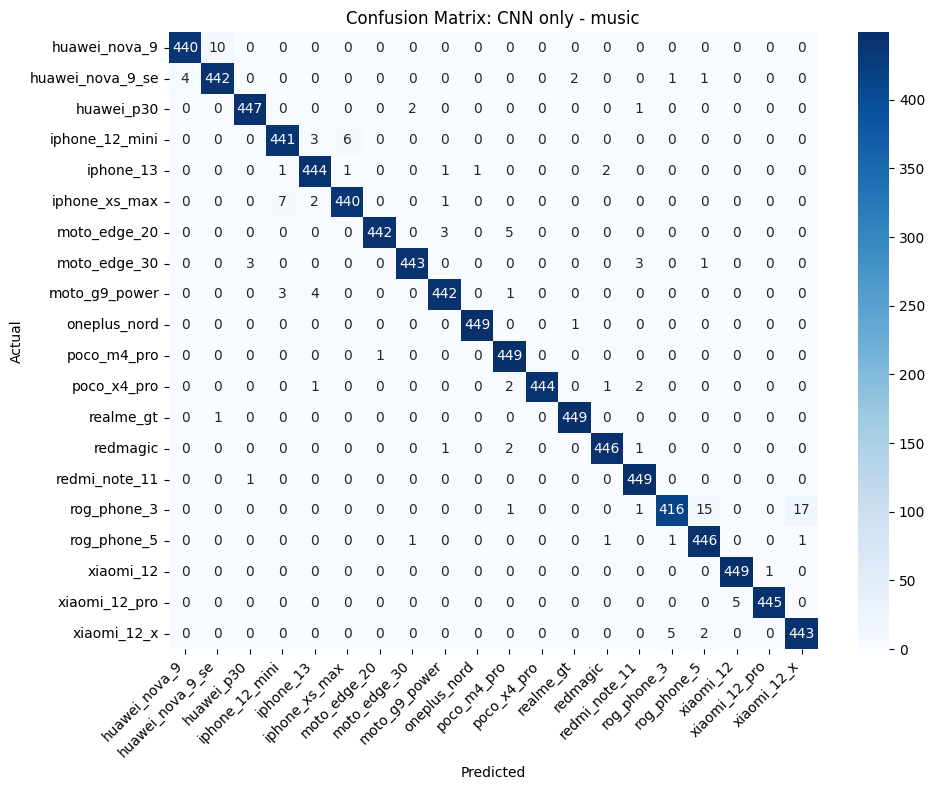


Misclassifications - CNN only:


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,10
1,huawei_nova_9_se,huawei_nova_9,4
2,huawei_nova_9_se,realme_gt,2
3,huawei_nova_9_se,rog_phone_3,1
4,huawei_nova_9_se,rog_phone_5,1
5,huawei_p30,moto_edge_30,2
6,huawei_p30,redmi_note_11,1
7,iphone_12_mini,iphone_13,3
8,iphone_12_mini,iphone_xs_max,6
9,iphone_13,iphone_12_mini,1



F1 Scores: CNN only:
 1. oneplus_nord         0.9978
 2. realme_gt            0.9956
 3. xiaomi_12            0.9934
 4. xiaomi_12_pro        0.9933
 5. poco_x4_pro          0.9933
 6. huawei_p30           0.9922
 7. redmagic             0.9911
 8. redmi_note_11        0.9901
 9. moto_edge_20         0.9899
10. moto_edge_30         0.9888
11. poco_m4_pro          0.9868
12. moto_g9_power        0.9844
13. huawei_nova_9        0.9843
14. iphone_13            0.9823
15. iphone_xs_max        0.9810
16. huawei_nova_9_se     0.9790
17. iphone_12_mini       0.9778
18. rog_phone_5          0.9749
19. xiaomi_12_x          0.9726
20. rog_phone_3          0.9530

Top 5:
1. oneplus_nord: 0.9978
2. realme_gt: 0.9956
3. xiaomi_12: 0.9934
4. xiaomi_12_pro: 0.9933
5. poco_x4_pro: 0.9933

Bottom 5:
16. huawei_nova_9_se: 0.9790
17. iphone_12_mini: 0.9778
18. rog_phone_5: 0.9749
19. xiaomi_12_x: 0.9726
20. rog_phone_3: 0.9530


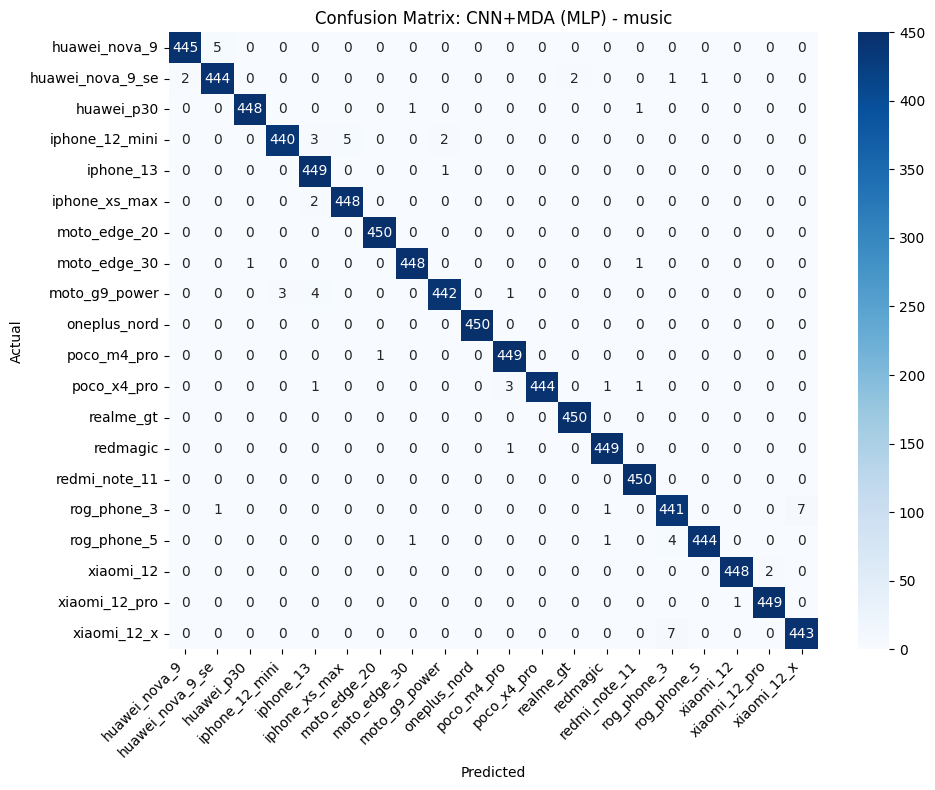


Misclassifications - CNN+MDA (MLP):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,5
1,huawei_nova_9_se,huawei_nova_9,2
2,huawei_nova_9_se,realme_gt,2
3,huawei_nova_9_se,rog_phone_3,1
4,huawei_nova_9_se,rog_phone_5,1
5,huawei_p30,moto_edge_30,1
6,huawei_p30,redmi_note_11,1
7,iphone_12_mini,iphone_13,3
8,iphone_12_mini,iphone_xs_max,5
9,iphone_12_mini,moto_g9_power,2



F1 Scores: CNN+MDA (MLP):
 1. oneplus_nord         1.0000
 2. moto_edge_20         0.9989
 3. realme_gt            0.9978
 4. redmi_note_11        0.9967
 5. xiaomi_12_pro        0.9967
 6. huawei_p30           0.9967
 7. xiaomi_12            0.9967
 8. redmagic             0.9956
 9. moto_edge_30         0.9956
10. poco_m4_pro          0.9934
11. poco_x4_pro          0.9933
12. iphone_xs_max        0.9922
13. huawei_nova_9        0.9922
14. rog_phone_5          0.9922
15. iphone_13            0.9879
16. moto_g9_power        0.9877
17. huawei_nova_9_se     0.9867
18. iphone_12_mini       0.9854
19. xiaomi_12_x          0.9844
20. rog_phone_3          0.9767

Top 5:
1. oneplus_nord: 1.0000
2. moto_edge_20: 0.9989
3. realme_gt: 0.9978
4. redmi_note_11: 0.9967
5. xiaomi_12_pro: 0.9967

Bottom 5:
16. moto_g9_power: 0.9877
17. huawei_nova_9_se: 0.9867
18. iphone_12_mini: 0.9854
19. xiaomi_12_x: 0.9844
20. rog_phone_3: 0.9767


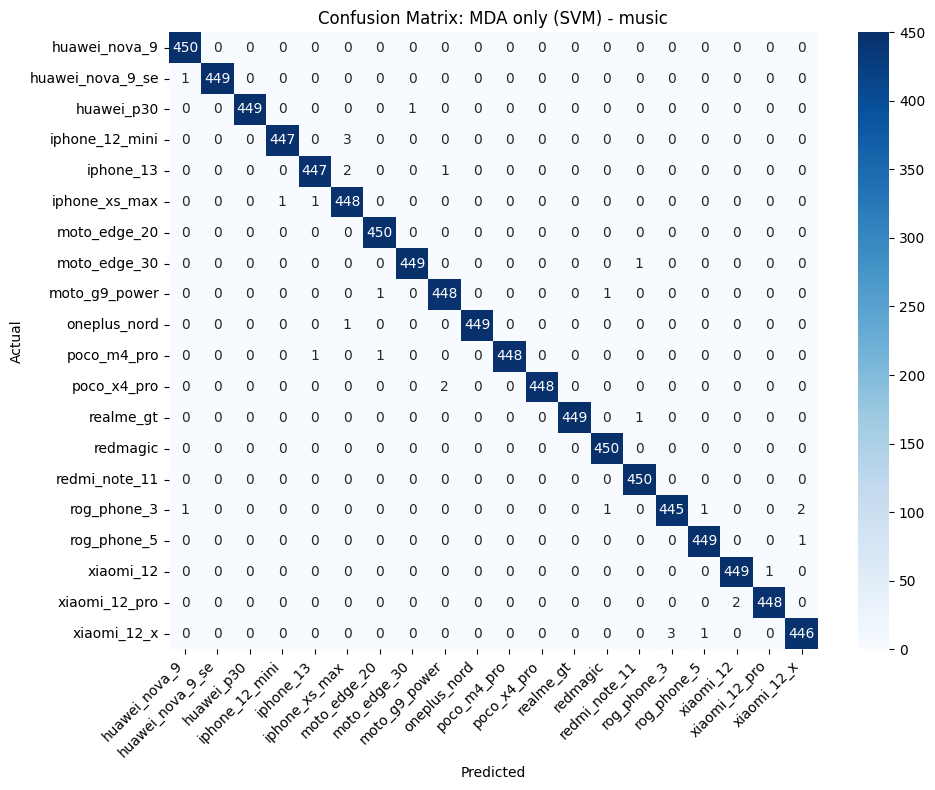


Misclassifications - MDA only (SVM):


,Actual,Predicted,Count
0,huawei_nova_9_se,huawei_nova_9,1
1,huawei_p30,moto_edge_30,1
2,iphone_12_mini,iphone_xs_max,3
3,iphone_13,iphone_xs_max,2
4,iphone_13,moto_g9_power,1
5,iphone_xs_max,iphone_12_mini,1
6,iphone_xs_max,iphone_13,1
7,moto_edge_30,redmi_note_11,1
8,moto_g9_power,moto_edge_20,1
9,moto_g9_power,redmagic,1



F1 Scores: MDA only (SVM):
 1. huawei_nova_9_se     0.9989
 2. huawei_p30           0.9989
 3. oneplus_nord         0.9989
 4. realme_gt            0.9989
 5. huawei_nova_9        0.9978
 6. moto_edge_20         0.9978
 7. redmagic             0.9978
 8. redmi_note_11        0.9978
 9. moto_edge_30         0.9978
10. poco_m4_pro          0.9978
11. poco_x4_pro          0.9978
12. rog_phone_5          0.9967
13. xiaomi_12            0.9967
14. xiaomi_12_pro        0.9967
15. iphone_12_mini       0.9955
16. moto_g9_power        0.9945
17. iphone_13            0.9944
18. xiaomi_12_x          0.9922
19. iphone_xs_max        0.9912
20. rog_phone_3          0.9911

Top 5:
1. huawei_nova_9_se: 0.9989
2. huawei_p30: 0.9989
3. oneplus_nord: 0.9989
4. realme_gt: 0.9989
5. huawei_nova_9: 0.9978

Bottom 5:
16. moto_g9_power: 0.9945
17. iphone_13: 0.9944
18. xiaomi_12_x: 0.9922
19. iphone_xs_max: 0.9912
20. rog_phone_3: 0.9911


In [14]:
music_kfold_results = train_condition_model(
    music_data['windows'], 
    music_data['label_indices'],
    music_data['file_tracking'],
    epochs=epochs,
    classifiers=classifiers,
    label_map=music_data['label_map'],
    condition_name="music",
    k_folds=k_folds,
    patience=patience,
    early_stopping_patience=early_stopping_patience,
    min_lr=min_lr
)

Files per class: Counter({'moto_edge_30': 300, 'huawei_nova_9': 294, 'xiaomi_12_x': 291, 'iphone_xs_max': 291, 'realme_gt': 289, 'iphone_12_mini': 288, 'redmi_note_11': 288, 'rog_phone_5': 287, 'huawei_p30': 286, 'iphone_13': 286, 'redmagic': 285, 'poco_m4_pro': 284, 'rog_phone_3': 284, 'poco_x4_pro': 284, 'xiaomi_12_pro': 283, 'oneplus_nord': 283, 'huawei_nova_9_se': 283, 'xiaomi_12': 281, 'moto_g9_power': 280, 'moto_edge_20': 278})
Creating 5 fold cross-validation splits
Total windows: 9000
Fold 1
Train samples per class: Counter({11: 301, 2: 299, 12: 298, 1: 294, 6: 292, 18: 291, 8: 291, 0: 291, 7: 289, 9: 288, 5: 288, 15: 283, 16: 283, 14: 283, 10: 283, 13: 283, 3: 281, 19: 280, 4: 278, 17: 276})
Val samples per class: Counter({3: 77, 6: 77, 1: 77, 17: 76, 16: 75, 4: 75, 19: 75, 13: 74, 9: 74, 5: 74, 15: 73, 18: 73, 8: 72, 7: 70, 14: 68, 2: 68, 10: 67, 11: 67, 0: 65, 12: 64})
Test samples per class: Counter({10: 100, 14: 99, 17: 98, 4: 97, 19: 95, 15: 94, 0: 94, 13: 93, 3: 92, 16: 

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.5117/0.5151 | Val: 1.0248/0.6912 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.4428/0.8567 | Val: 0.5245/0.8293 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.2362/0.9232 | Val: 0.4240/0.8550 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.1417/0.9543 | Val: 0.4820/0.8515 | LR: 0.001000
Epoch [ 6/35] | Train: 0.1150/0.9612 | Val: 0.4114/0.8806 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.0688/0.9774 | Val: 0.3911/0.8876 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0508/0.9837 | Val: 0.3845/0.9035 | LR: 0.001000 - lowest loss so far
Epoch [11/35] | Train: 0.0421/0.9873 | Val: 0.3708/0.9028 | LR: 0.001000 - lowest loss so far
Epoch [12/35] | Train: 0.0337/0.9882 | Val: 0.3662/0.9008 | LR: 0.001000 - lowest loss so far
Epoch [13/35] | Train: 0.0295/0.9915 | Val: 0.3430/0.9022 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0270/0.9913 | Val: 0.3854/0.9022 | LR: 0.001000
Epoch [1

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.4645/0.5233 | Val: 0.7947/0.7221 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.4695/0.8445 | Val: 0.6348/0.7937 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.2970/0.9021 | Val: 0.4193/0.8625 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.1406/0.9532 | Val: 0.4366/0.8709 | LR: 0.001000
Epoch [ 8/35] | Train: 0.0771/0.9749 | Val: 0.4085/0.8702 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0462/0.9871 | Val: 0.4148/0.8891 | LR: 0.001000
Epoch [11/35] | Train: 0.0499/0.9852 | Val: 0.3541/0.9032 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0381/0.9892 | Val: 0.3567/0.9025 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.3541 at epoch 11
Restored model validation accuracy: 0.9032, validation loss: 0.3651
CNN only accuracy: 0.8966
CNN training (fold 2): 27.87 seconds
MDA only training (fold 2): 22.94 seconds


...

Epoch [ 1/35] | Train: 1.5934/0.4781 | Val: 1.0375/0.6758 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.5416/0.8231 | Val: 0.5161/0.8372 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.2907/0.9062 | Val: 0.4606/0.8551 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.1808/0.9402 | Val: 0.3287/0.9052 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0752/0.9786 | Val: 0.3115/0.8970 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0792/0.9758 | Val: 0.3924/0.8791 | LR: 0.001000
Epoch [15/35] | Train: 0.0500/0.9831 | Val: 0.3981/0.9018 | LR: 0.000500
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.3115 at epoch 7
Restored model validation accuracy: 0.8970, validation loss: 0.3360
CNN only accuracy: 0.9109
CNN training (fold 3): 22.00 seconds
MDA only training (fold 3): 23.22 seconds
CNN + MDA combined
CNN feature shapes - Train: (5737, 512), Val: (1456, 51

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.3768/0.5534 | Val: 0.7832/0.7311 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.4220/0.8653 | Val: 0.3916/0.8655 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.1989/0.9365 | Val: 0.3617/0.8908 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.1548/0.9489 | Val: 0.3235/0.8901 | LR: 0.001000 - lowest loss so far
Epoch [ 6/35] | Train: 0.1017/0.9677 | Val: 0.2754/0.9076 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0938/0.9705 | Val: 0.2720/0.9139 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0545/0.9822 | Val: 0.3565/0.9034 | LR: 0.001000
Epoch [11/35] | Train: 0.0517/0.9850 | Val: 0.2678/0.9188 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0428/0.9860 | Val: 0.2820/0.9146 | LR: 0.001000
Epoch [16/35] | Train: 0.0246/0.9943 | Val: 0.2648/0.9209 | LR: 0.001000 - lowest loss so far
Epoch [18/35] | Train: 0.0072/0.9983 | Val: 0.2516/0.9300 | LR: 0.001000 - lowest loss so far
Epoch [1

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.3488/0.5683 | Val: 0.7055/0.7666 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.4630/0.8493 | Val: 0.5609/0.8209 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.3834/0.8833 | Val: 0.4283/0.8593 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.3325/0.8907 | Val: 0.4135/0.8641 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.2109/0.9304 | Val: 0.2797/0.9039 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.2111/0.9351 | Val: 0.2681/0.9156 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.1000/0.9677 | Val: 0.2263/0.9355 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.2150/0.9332 | Val: 0.2651/0.9293 | LR: 0.001000
Epoch [18/35] | Train: 0.0118/0.9977 | Val: 0.2123/0.9417 | LR: 0.001000 - lowest loss so far
Epoch [20/35] | Train: 0.0104/0.9977 | Val: 0.2002/0.9465 | LR: 0.001000 - lowest loss so far
Epoch [25/35] | Train: 0.0831/0.9747 | Val: 0.2181/0.9334 | LR: 0.001000
LR reduc

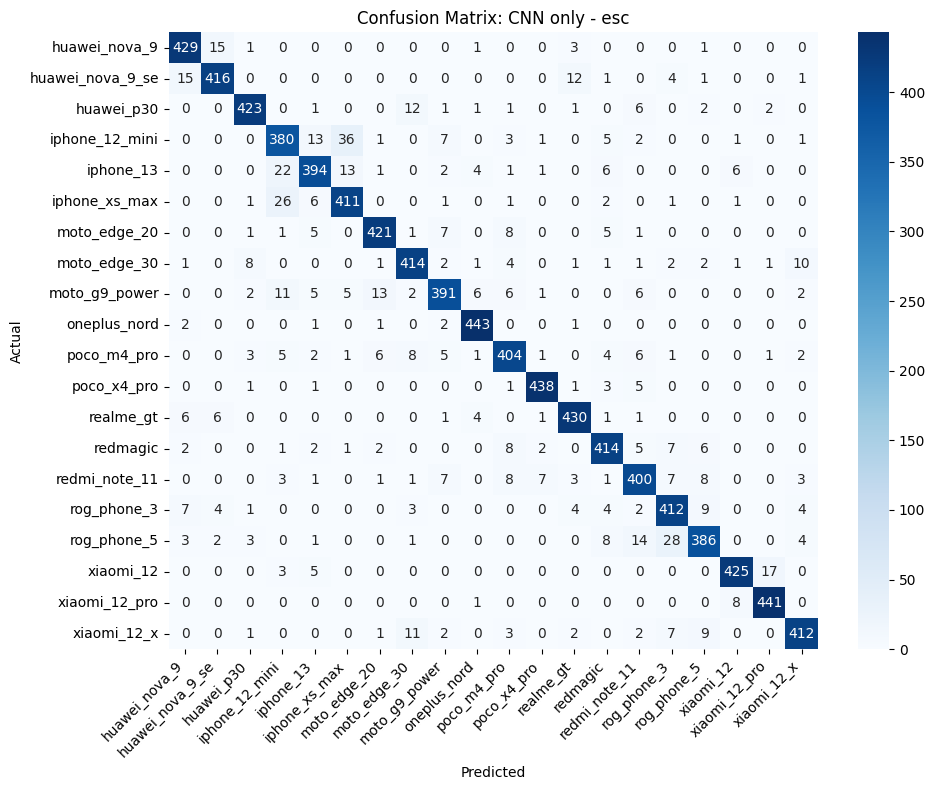


Misclassifications - CNN only:


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,15
1,huawei_nova_9,huawei_p30,1
2,huawei_nova_9,oneplus_nord,1
3,huawei_nova_9,realme_gt,3
4,huawei_nova_9,rog_phone_5,1
...,...,...,...
161,xiaomi_12_x,poco_m4_pro,3
162,xiaomi_12_x,realme_gt,2
163,xiaomi_12_x,redmi_note_11,2
164,xiaomi_12_x,rog_phone_3,7



F1 Scores: CNN only:
 1. oneplus_nord         0.9715
 2. poco_x4_pro          0.9712
 3. xiaomi_12_pro        0.9671
 4. xiaomi_12            0.9529
 5. realme_gt            0.9471
 6. huawei_p30           0.9453
 7. huawei_nova_9        0.9377
 8. moto_edge_20         0.9376
 9. huawei_nova_9_se     0.9317
10. xiaomi_12_x          0.9269
11. moto_edge_30         0.9169
12. redmagic             0.9149
13. poco_m4_pro          0.8998
14. rog_phone_3          0.8966
15. iphone_xs_max        0.8964
16. moto_g9_power        0.8907
17. iphone_13            0.8884
18. redmi_note_11        0.8879
19. rog_phone_5          0.8833
20. iphone_12_mini       0.8426

Top 5:
1. oneplus_nord: 0.9715
2. poco_x4_pro: 0.9712
3. xiaomi_12_pro: 0.9671
4. xiaomi_12: 0.9529
5. realme_gt: 0.9471

Bottom 5:
16. moto_g9_power: 0.8907
17. iphone_13: 0.8884
18. redmi_note_11: 0.8879
19. rog_phone_5: 0.8833
20. iphone_12_mini: 0.8426


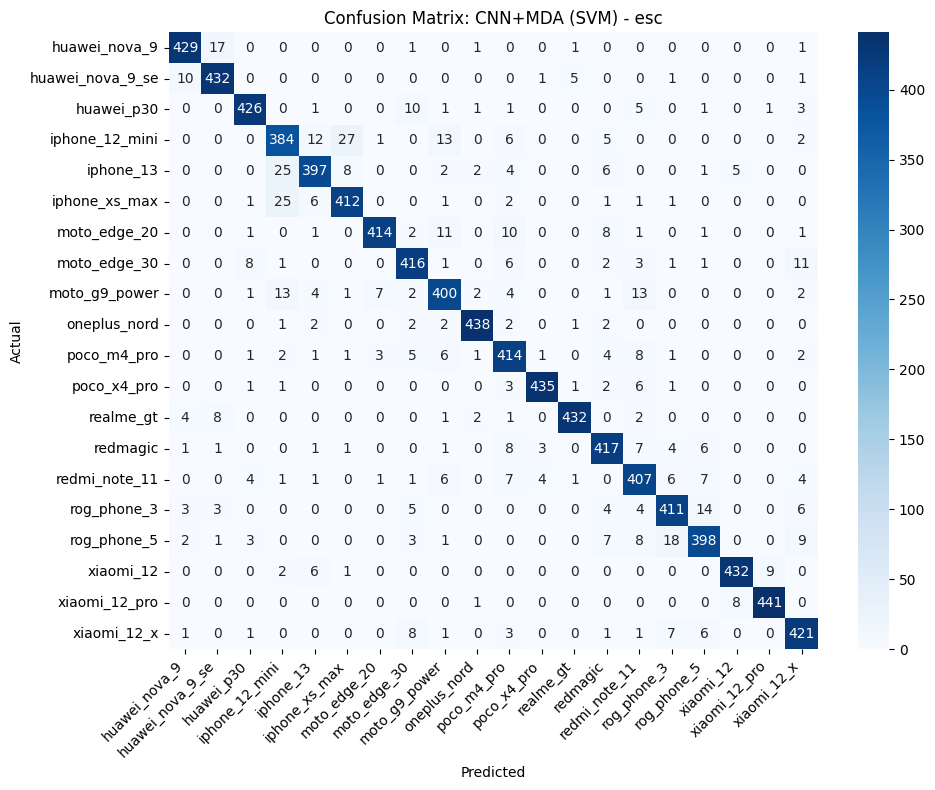


Misclassifications - CNN+MDA (SVM):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,17
1,huawei_nova_9,moto_edge_30,1
2,huawei_nova_9,oneplus_nord,1
3,huawei_nova_9,realme_gt,1
4,huawei_nova_9,xiaomi_12_x,1
...,...,...,...
152,xiaomi_12_x,poco_m4_pro,3
153,xiaomi_12_x,redmagic,1
154,xiaomi_12_x,redmi_note_11,1
155,xiaomi_12_x,rog_phone_3,7



F1 Scores: CNN+MDA (SVM):
 1. xiaomi_12_pro        0.9789
 2. oneplus_nord         0.9755
 3. poco_x4_pro          0.9732
 4. realme_gt            0.9697
 5. xiaomi_12            0.9654
 6. huawei_nova_9        0.9533
 7. huawei_p30           0.9498
 8. huawei_nova_9_se     0.9474
 9. moto_edge_20         0.9452
10. xiaomi_12_x          0.9222
11. moto_edge_30         0.9193
12. redmagic             0.9165
13. iphone_xs_max        0.9145
14. rog_phone_3          0.9123
15. iphone_13            0.9002
16. rog_phone_5          0.8994
17. poco_m4_pro          0.8990
18. moto_g9_power        0.8919
19. redmi_note_11        0.8886
20. iphone_12_mini       0.8486

Top 5:
1. xiaomi_12_pro: 0.9789
2. oneplus_nord: 0.9755
3. poco_x4_pro: 0.9732
4. realme_gt: 0.9697
5. xiaomi_12: 0.9654

Bottom 5:
16. rog_phone_5: 0.8994
17. poco_m4_pro: 0.8990
18. moto_g9_power: 0.8919
19. redmi_note_11: 0.8886
20. iphone_12_mini: 0.8486


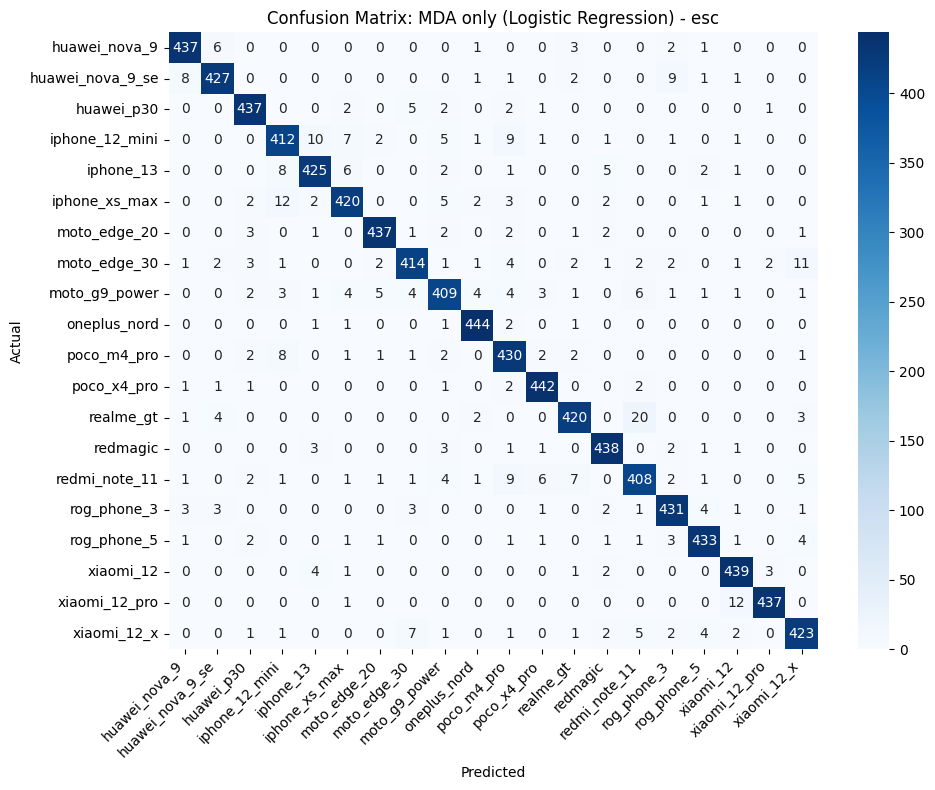


Misclassifications - MDA only (Logistic Regression):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,6
1,huawei_nova_9,oneplus_nord,1
2,huawei_nova_9,realme_gt,3
3,huawei_nova_9,rog_phone_3,2
4,huawei_nova_9,rog_phone_5,1
...,...,...,...
161,xiaomi_12_x,redmagic,2
162,xiaomi_12_x,redmi_note_11,5
163,xiaomi_12_x,rog_phone_3,2
164,xiaomi_12_x,rog_phone_5,4



F1 Scores: MDA only (Logistic Regression):
 1. oneplus_nord         0.9791
 2. xiaomi_12_pro        0.9787
 3. poco_x4_pro          0.9736
 4. moto_edge_20         0.9722
 5. huawei_nova_9        0.9679
 6. redmagic             0.9669
 7. huawei_p30           0.9657
 8. rog_phone_5          0.9633
 9. xiaomi_12            0.9627
10. huawei_nova_9_se     0.9563
11. rog_phone_3          0.9525
12. iphone_13            0.9476
13. realme_gt            0.9428
14. xiaomi_12_x          0.9400
15. iphone_xs_max        0.9385
16. moto_edge_30         0.9345
17. poco_m4_pro          0.9328
18. moto_g9_power        0.9212
19. iphone_12_mini       0.9196
20. redmi_note_11        0.9117

Top 5:
1. oneplus_nord: 0.9791
2. xiaomi_12_pro: 0.9787
3. poco_x4_pro: 0.9736
4. moto_edge_20: 0.9722
5. huawei_nova_9: 0.9679

Bottom 5:
16. moto_edge_30: 0.9345
17. poco_m4_pro: 0.9328
18. moto_g9_power: 0.9212
19. iphone_12_mini: 0.9196
20. redmi_note_11: 0.9117


In [15]:
esc_kfold_results = train_condition_model(
    esc_data['windows'], 
    esc_data['label_indices'],
    esc_data['file_tracking'],
    epochs=epochs,
    classifiers=classifiers,
    label_map=esc_data['label_map'],
    condition_name="esc",
    k_folds=k_folds,
    patience=patience,
    early_stopping_patience=early_stopping_patience,
    min_lr=min_lr
)

Files per class: Counter({'xiaomi_12_x': 221, 'redmi_note_11': 217, 'huawei_p30': 216, 'moto_edge_30': 216, 'iphone_xs_max': 216, 'realme_gt': 216, 'moto_g9_power': 215, 'iphone_13': 215, 'oneplus_nord': 215, 'huawei_nova_9': 214, 'iphone_12_mini': 214, 'moto_edge_20': 213, 'rog_phone_5': 213, 'xiaomi_12_pro': 212, 'poco_m4_pro': 211, 'poco_x4_pro': 211, 'rog_phone_3': 210, 'xiaomi_12': 209, 'huawei_nova_9_se': 208, 'redmagic': 208})
Creating 5 fold cross-validation splits
Total windows: 8960
Fold 1
Train samples per class: Counter({14: 305, 10: 303, 17: 302, 0: 300, 2: 300, 13: 300, 1: 297, 12: 294, 6: 292, 16: 289, 15: 285, 18: 285, 19: 285, 4: 284, 9: 284, 5: 281, 7: 281, 11: 279, 8: 276, 3: 274})
Val samples per class: Counter({8: 96, 3: 90, 11: 85, 7: 83, 5: 81, 6: 79, 19: 79, 17: 78, 4: 77, 16: 76, 9: 73, 10: 73, 18: 73, 2: 71, 13: 69, 0: 67, 15: 67, 12: 63, 14: 63, 1: 51})
Test samples per class: Counter({1: 100, 15: 96, 9: 91, 12: 91, 18: 90, 4: 87, 5: 86, 3: 84, 7: 84, 11: 84,

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.2729/0.5840 | Val: 0.7422/0.7530 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.2940/0.9039 | Val: 0.3217/0.8969 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.1564/0.9494 | Val: 0.2086/0.9344 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0885/0.9715 | Val: 0.2314/0.9351 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0732/0.9784 | Val: 0.1986/0.9444 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0455/0.9879 | Val: 0.1895/0.9458 | LR: 0.001000 - lowest loss so far
Epoch [11/35] | Train: 0.0271/0.9922 | Val: 0.1774/0.9471 | LR: 0.001000 - lowest loss so far
Epoch [12/35] | Train: 0.0301/0.9903 | Val: 0.1758/0.9451 | LR: 0.001000 - lowest loss so far
Epoch [14/35] | Train: 0.0148/0.9948 | Val: 0.1157/0.9699 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0133/0.9965 | Val: 0.1722/0.9545 | LR: 0.001000
Epoch [20/35] | Train: 0.0119/0.9959 | Val: 0.1289/0.9665 | LR: 0.001000
Epoch [21/35] | Train: 0.0028

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.3525/0.5616 | Val: 0.4885/0.8291 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.1907/0.9408 | Val: 0.2727/0.9174 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.1255/0.9602 | Val: 0.2050/0.9356 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0969/0.9686 | Val: 0.2373/0.9258 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0880/0.9704 | Val: 0.2034/0.9363 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0520/0.9848 | Val: 0.1608/0.9461 | LR: 0.001000 - lowest loss so far
Epoch [ 9/35] | Train: 0.0379/0.9891 | Val: 0.1550/0.9475 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0383/0.9869 | Val: 0.1639/0.9552 | LR: 0.001000
Epoch [15/35] | Train: 0.0293/0.9928 | Val: 0.2300/0.9321 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.1550 at epoch 9
Restored model validation accuracy: 0.9475, validation loss: 0.1606
CNN only acc

...

Epoch [ 1/35] | Train: 1.0855/0.6577 | Val: 0.5202/0.8230 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.2828/0.9099 | Val: 0.2688/0.9084 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.1358/0.9551 | Val: 0.2332/0.9316 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0817/0.9758 | Val: 0.2438/0.9282 | LR: 0.001000
Epoch [ 8/35] | Train: 0.0602/0.9825 | Val: 0.1626/0.9556 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0467/0.9863 | Val: 0.2139/0.9392 | LR: 0.001000
Epoch [15/35] | Train: 0.0107/0.9974 | Val: 0.1793/0.9624 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.1626 at epoch 8
Restored model validation accuracy: 0.9556, validation loss: 0.1706
CNN only accuracy: 0.9509
CNN training (fold 3): 24.99 seconds
MDA only training (fold 3): 24.63 seconds
CNN + MDA combined
CNN feature shapes - Train: (5703, 512), Val: (1463, 512), Test: (1794, 512)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.2378/0.6026 | Val: 0.6307/0.7937 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.2747/0.9157 | Val: 0.2588/0.9151 | LR: 0.001000 - lowest loss so far
Epoch [ 3/35] | Train: 0.1695/0.9455 | Val: 0.2366/0.9256 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.1186/0.9601 | Val: 0.3122/0.8891 | LR: 0.001000
Epoch [ 7/35] | Train: 0.0812/0.9717 | Val: 0.2179/0.9291 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0553/0.9833 | Val: 0.1808/0.9502 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0296/0.9914 | Val: 0.1671/0.9530 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0318/0.9903 | Val: 0.1956/0.9453 | LR: 0.001000
LR reduced: 0.001000 → 0.000500
Early stopping after 8 epochs without improvement
Training done, best validation loss: 0.1671 at epoch 10
Restored model validation accuracy: 0.9530, validation loss: 0.1802
CNN only accuracy: 0.9457
CNN training (fold 4): 27.73 seconds
MDA only training (fo

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [ 1/35] | Train: 1.3455/0.5718 | Val: 0.5444/0.8240 | LR: 0.001000 - lowest loss so far
Epoch [ 2/35] | Train: 0.2620/0.9125 | Val: 0.3195/0.9060 | LR: 0.001000 - lowest loss so far
Epoch [ 4/35] | Train: 0.1316/0.9575 | Val: 0.3177/0.8948 | LR: 0.001000 - lowest loss so far
Epoch [ 5/35] | Train: 0.0772/0.9762 | Val: 0.2520/0.9239 | LR: 0.001000 - lowest loss so far
Epoch [ 6/35] | Train: 0.0545/0.9826 | Val: 0.2469/0.9272 | LR: 0.001000 - lowest loss so far
Epoch [ 7/35] | Train: 0.0452/0.9874 | Val: 0.2448/0.9338 | LR: 0.001000 - lowest loss so far
Epoch [ 8/35] | Train: 0.0301/0.9918 | Val: 0.1850/0.9504 | LR: 0.001000 - lowest loss so far
Epoch [10/35] | Train: 0.0443/0.9868 | Val: 0.2821/0.9107 | LR: 0.001000
Epoch [14/35] | Train: 0.0223/0.9950 | Val: 0.1742/0.9517 | LR: 0.001000 - lowest loss so far
Epoch [15/35] | Train: 0.0085/0.9982 | Val: 0.1753/0.9543 | LR: 0.001000
Epoch [16/35] | Train: 0.0070/0.9988 | Val: 0.1432/0.9636 | LR: 0.001000 - lowest loss so far
Epoch [2

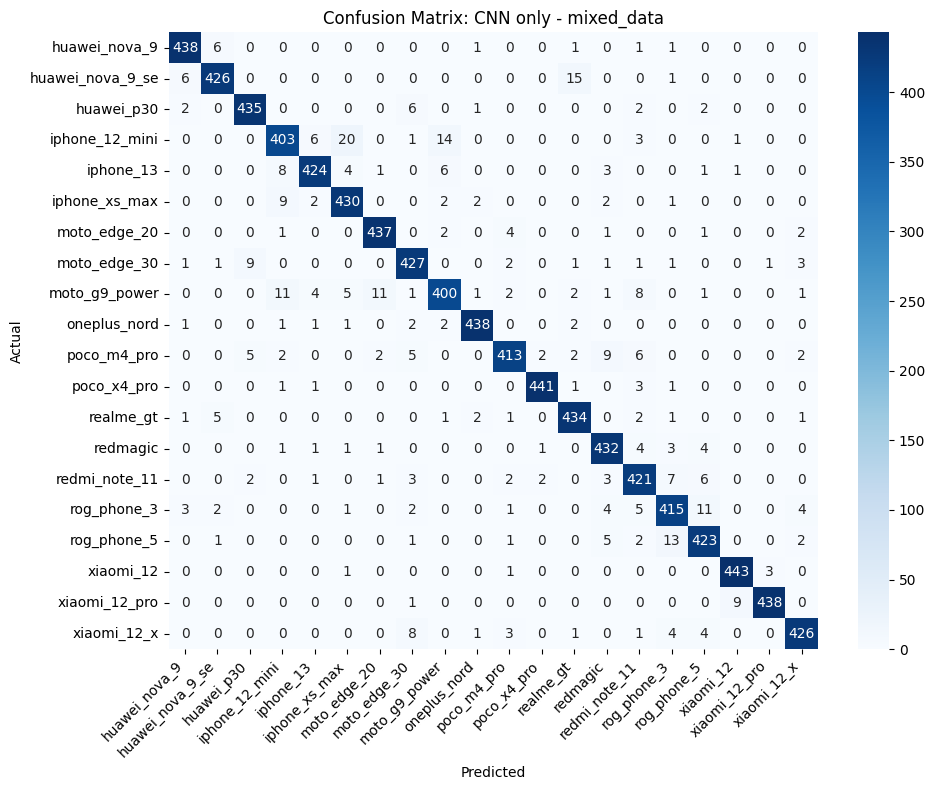


Misclassifications - CNN only:


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,6
1,huawei_nova_9,oneplus_nord,1
2,huawei_nova_9,realme_gt,1
3,huawei_nova_9,redmi_note_11,1
4,huawei_nova_9,rog_phone_3,1
...,...,...,...
129,xiaomi_12_x,poco_m4_pro,3
130,xiaomi_12_x,realme_gt,1
131,xiaomi_12_x,redmi_note_11,1
132,xiaomi_12_x,rog_phone_3,4



F1 Scores: CNN only:
 1. poco_x4_pro          0.9866
 2. xiaomi_12_pro        0.9843
 3. xiaomi_12            0.9823
 4. oneplus_nord         0.9799
 5. huawei_nova_9        0.9733
 6. moto_edge_20         0.9700
 7. huawei_p30           0.9677
 8. huawei_nova_9_se     0.9584
 9. xiaomi_12_x          0.9584
10. realme_gt            0.9570
11. iphone_13            0.9550
12. redmagic             0.9505
13. iphone_xs_max        0.9440
14. moto_edge_30         0.9436
15. poco_m4_pro          0.9408
16. rog_phone_5          0.9390
17. redmi_note_11        0.9283
18. rog_phone_3          0.9263
19. moto_g9_power        0.9143
20. iphone_12_mini       0.9107

Top 5:
1. poco_x4_pro: 0.9866
2. xiaomi_12_pro: 0.9843
3. xiaomi_12: 0.9823
4. oneplus_nord: 0.9799
5. huawei_nova_9: 0.9733

Bottom 5:
16. rog_phone_5: 0.9390
17. redmi_note_11: 0.9283
18. rog_phone_3: 0.9263
19. moto_g9_power: 0.9143
20. iphone_12_mini: 0.9107


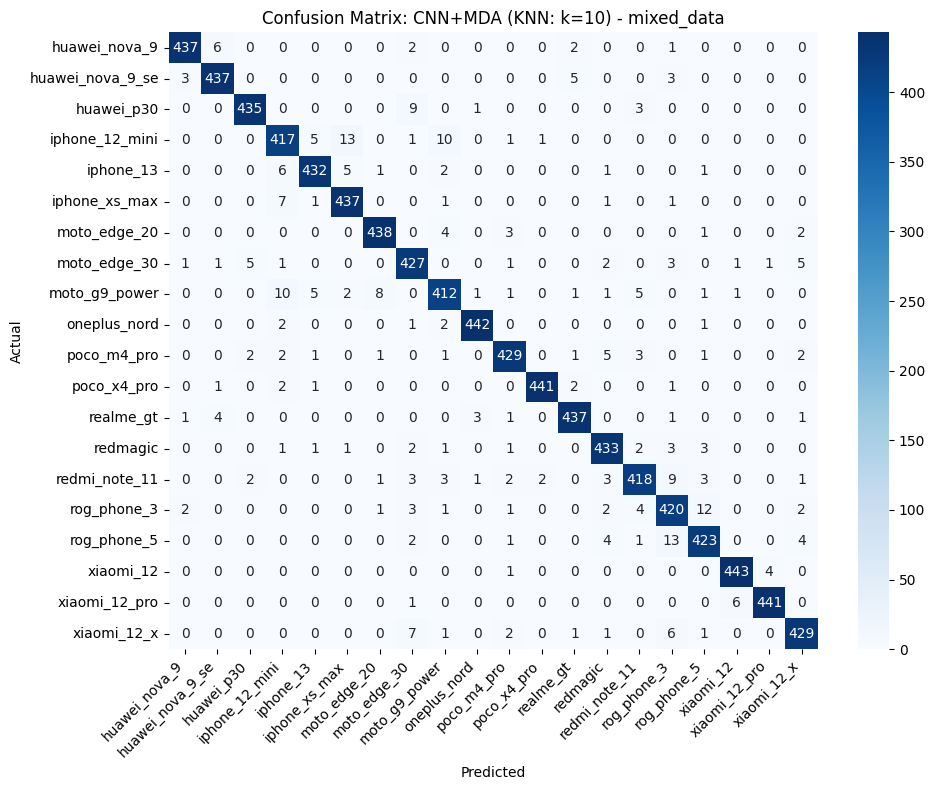


Misclassifications - CNN+MDA (KNN: k=10):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,6
1,huawei_nova_9,moto_edge_30,2
2,huawei_nova_9,realme_gt,2
3,huawei_nova_9,rog_phone_3,1
4,huawei_nova_9_se,huawei_nova_9,3
...,...,...,...
118,xiaomi_12_x,poco_m4_pro,2
119,xiaomi_12_x,realme_gt,1
120,xiaomi_12_x,redmagic,1
121,xiaomi_12_x,rog_phone_3,6



F1 Scores: CNN+MDA (KNN: k=10):
 1. poco_x4_pro          0.9888
 2. oneplus_nord         0.9866
 3. xiaomi_12_pro        0.9866
 4. xiaomi_12            0.9855
 5. huawei_nova_9        0.9798
 6. moto_edge_20         0.9755
 7. huawei_p30           0.9753
 8. huawei_nova_9_se     0.9744
 9. realme_gt            0.9744
10. iphone_13            0.9664
11. iphone_xs_max        0.9647
12. poco_m4_pro          0.9619
13. redmagic             0.9612
14. xiaomi_12_x          0.9597
15. redmi_note_11        0.9457
16. rog_phone_5          0.9453
17. moto_edge_30         0.9426
18. iphone_12_mini       0.9308
19. moto_g9_power        0.9300
20. rog_phone_3          0.9241

Top 5:
1. poco_x4_pro: 0.9888
2. oneplus_nord: 0.9866
3. xiaomi_12_pro: 0.9866
4. xiaomi_12: 0.9855
5. huawei_nova_9: 0.9798

Bottom 5:
16. rog_phone_5: 0.9453
17. moto_edge_30: 0.9426
18. iphone_12_mini: 0.9308
19. moto_g9_power: 0.9300
20. rog_phone_3: 0.9241


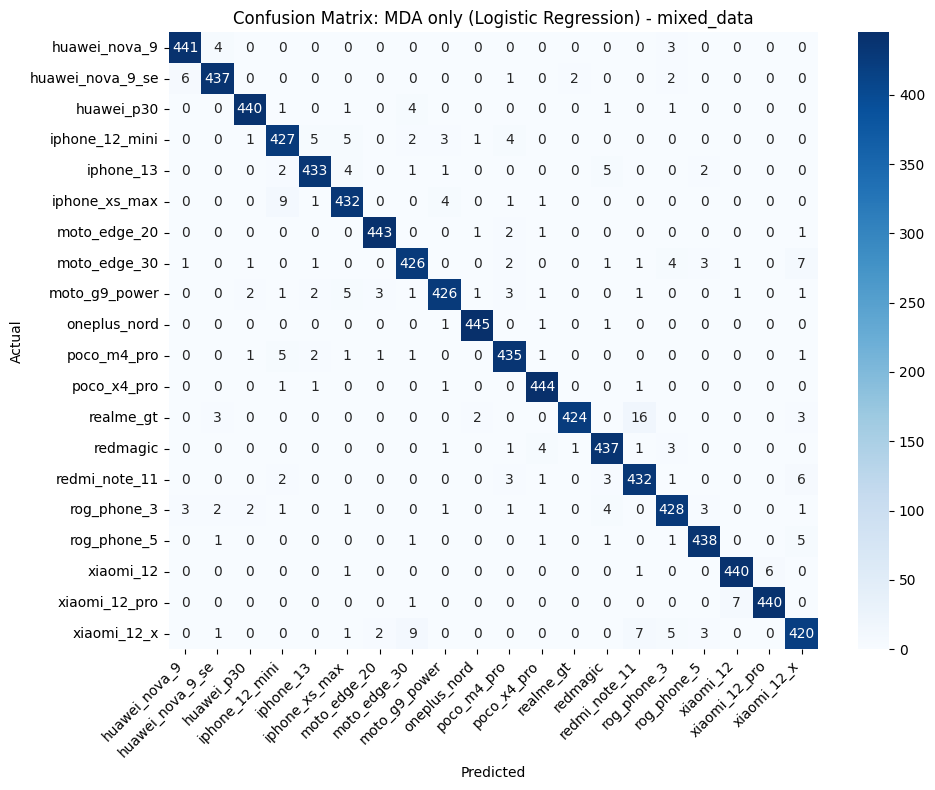


Misclassifications - MDA only (Logistic Regression):


,Actual,Predicted,Count
0,huawei_nova_9,huawei_nova_9_se,4
1,huawei_nova_9,rog_phone_3,3
2,huawei_nova_9_se,huawei_nova_9,6
3,huawei_nova_9_se,poco_m4_pro,1
4,huawei_nova_9_se,realme_gt,2
...,...,...,...
110,xiaomi_12_x,moto_edge_20,2
111,xiaomi_12_x,moto_edge_30,9
112,xiaomi_12_x,redmi_note_11,7
113,xiaomi_12_x,rog_phone_3,5



F1 Scores: MDA only (Logistic Regression):
 1. oneplus_nord         0.9911
 2. moto_edge_20         0.9877
 3. xiaomi_12_pro        0.9843
 4. huawei_p30           0.9832
 5. poco_x4_pro          0.9823
 6. huawei_nova_9        0.9811
 7. xiaomi_12            0.9810
 8. rog_phone_5          0.9766
 9. huawei_nova_9_se     0.9754
10. redmagic             0.9700
11. iphone_13            0.9698
12. realme_gt            0.9691
13. poco_m4_pro          0.9656
14. moto_g9_power        0.9616
15. iphone_xs_max        0.9611
16. rog_phone_3          0.9554
17. moto_edge_30         0.9530
18. iphone_12_mini       0.9521
19. redmi_note_11        0.9515
20. xiaomi_12_x          0.9406

Top 5:
1. oneplus_nord: 0.9911
2. moto_edge_20: 0.9877
3. xiaomi_12_pro: 0.9843
4. huawei_p30: 0.9832
5. poco_x4_pro: 0.9823

Bottom 5:
16. rog_phone_3: 0.9554
17. moto_edge_30: 0.9530
18. iphone_12_mini: 0.9521
19. redmi_note_11: 0.9515
20. xiaomi_12_x: 0.9406


In [16]:
mixed_kfold_results = train_condition_model(
    mixed_data['windows'], 
    mixed_data['label_indices'],
    mixed_data['file_tracking'],
    epochs=epochs,
    classifiers=classifiers,
    label_map=mixed_data['label_map'],
    condition_name="mixed_data",
    k_folds=k_folds,
    patience=patience,
    early_stopping_patience=early_stopping_patience,
    min_lr=min_lr
)


# Calculate mean ± std for each condition and method

                     CNN Only          CNN+MDA         MDA Only
speech_clean  0.9907 ± 0.0046  0.9928 ± 0.0019  0.9977 ± 0.0010
speech_noise  0.9977 ± 0.0039  0.9983 ± 0.0022  0.9996 ± 0.0006
music         0.9851 ± 0.0047  0.9924 ± 0.0015  0.9964 ± 0.0006
esc10         0.9206 ± 0.0152  0.9285 ± 0.0102  0.9515 ± 0.0066
mixed_data    0.9537 ± 0.0056  0.9630 ± 0.0040  0.9695 ± 0.0043


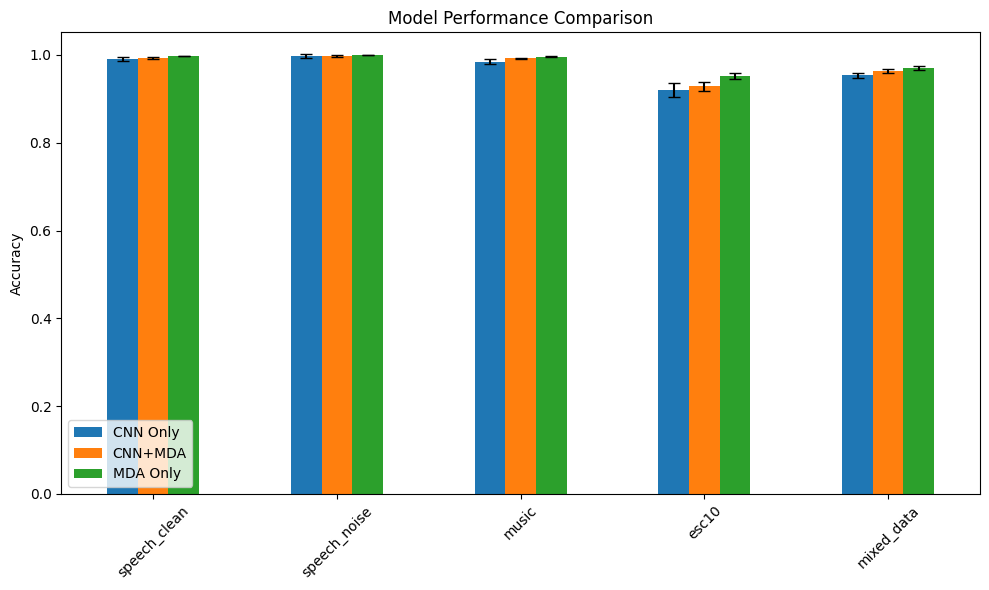

In [17]:
results = {
    'speech_clean': speech_clean_kfold_results,
    'speech_noise': speech_noise_kfold_results, 
    'music': music_kfold_results,
    'esc10': esc_kfold_results,
    'mixed_data': mixed_kfold_results
}

combined_data = []
mean_data = []
std_data = []

for condition, folds in results.items():
    combined_row = []
    mean_row = []
    std_row = []
    
    # CNN Only
    cnn_scores = [f.cnn_only_accuracy for f in folds]
    cnn_mean, cnn_std = np.mean(cnn_scores), np.std(cnn_scores)
    combined_row.append(f"{cnn_mean:.4f} ± {cnn_std:.4f}")
    mean_row.append(cnn_mean)
    std_row.append(cnn_std)
    
    # best CNN+MDA
    cnn_mda_scores = {}
    for f in folds:
        for clf, score in f.cnn_mda_results.items():
            cnn_mda_scores.setdefault(clf, []).append(score)
    best_cnn_mda = max(cnn_mda_scores, key=lambda x: np.mean(cnn_mda_scores[x]))
    cnn_mda_mean, cnn_mda_std = np.mean(cnn_mda_scores[best_cnn_mda]), np.std(cnn_mda_scores[best_cnn_mda])
    combined_row.append(f"{cnn_mda_mean:.4f} ± {cnn_mda_std:.4f}")
    mean_row.append(cnn_mda_mean)
    std_row.append(cnn_mda_std)
    
    # best MDA-only
    mda_scores = {}
    for f in folds:
        for clf, score in f.mda_only_results.items():
            mda_scores.setdefault(clf, []).append(score)
    best_mda = max(mda_scores, key=lambda x: np.mean(mda_scores[x]))
    mda_mean, mda_std = np.mean(mda_scores[best_mda]), np.std(mda_scores[best_mda])
    combined_row.append(f"{mda_mean:.4f} ± {mda_std:.4f}")
    mean_row.append(mda_mean)
    std_row.append(mda_std)
    
    combined_data.append(combined_row)
    mean_data.append(mean_row)
    std_data.append(std_row)

df = pd.DataFrame(combined_data, 
                  index=list(results.keys()),
                  columns=['CNN Only', 'CNN+MDA', 'MDA Only'])
print(df)

df_mean = pd.DataFrame(mean_data, index=list(results.keys()), columns=['CNN Only', 'CNN+MDA', 'MDA Only'])
df_std = pd.DataFrame(std_data, index=list(results.keys()), columns=['CNN Only', 'CNN+MDA', 'MDA Only'])

ax = df_mean.plot(kind='bar', figsize=(10, 6), 
                  title='Model Performance Comparison',
                  yerr=df_std, capsize=4)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Paired t-tests comparing methods across all conditions

In [18]:
conditions = list(results.keys())
methods = ['cnn_only', 'mda_only', 'cnn_mda']
    
for condition_name, fold_results in results.items():
    print(f"\n{condition_name.upper()}:")
        
    cnn_only_scores = [f.cnn_only_accuracy for f in fold_results]
    mda_only_scores = []
    for f in fold_results:
        best_mda_score = max(f.mda_only_results.values())
        mda_only_scores.append(best_mda_score)

    cnn_mda_scores = []
    for f in fold_results:
        best_cnn_mda_score = max(f.cnn_mda_results.values())
        cnn_mda_scores.append(best_cnn_mda_score)
        
    method_scores = {
        'cnn_only': cnn_only_scores,
        'mda_only': mda_only_scores,
        'cnn_mda': cnn_mda_scores
    }
        
    # paired t-tests for all combinations
    for method1, method2 in itertools.combinations(methods, 2):
        t_stat, p_value = stats.ttest_rel(method_scores[method1], method_scores[method2])
        print(f"  {method1} vs {method2}: t={t_stat:.3f}, p={p_value:.4f}")


SPEECH_CLEAN:
  cnn_only vs mda_only: t=-3.843, p=0.0184
  cnn_only vs cnn_mda: t=-1.329, p=0.2545
  mda_only vs cnn_mda: t=4.167, p=0.0141

SPEECH_NOISE:
  cnn_only vs mda_only: t=-1.152, p=0.3134
  cnn_only vs cnn_mda: t=-0.975, p=0.3846
  mda_only vs cnn_mda: t=1.283, p=0.2688

MUSIC:
  cnn_only vs mda_only: t=-4.502, p=0.0108
  cnn_only vs cnn_mda: t=-3.965, p=0.0166
  mda_only vs cnn_mda: t=4.753, p=0.0090

ESC10:
  cnn_only vs mda_only: t=-4.443, p=0.0113
  cnn_only vs cnn_mda: t=-2.482, p=0.0681
  mda_only vs cnn_mda: t=5.525, p=0.0052

MIXED_DATA:
  cnn_only vs mda_only: t=-3.561, p=0.0236
  cnn_only vs cnn_mda: t=-3.540, p=0.0240
  mda_only vs cnn_mda: t=2.250, p=0.0876


Overall Average Performance:
CNN Only: 0.9696 ± 0.0068
CNN+MDA: 0.9750 ± 0.0040
MDA Only: 0.9829 ± 0.0026



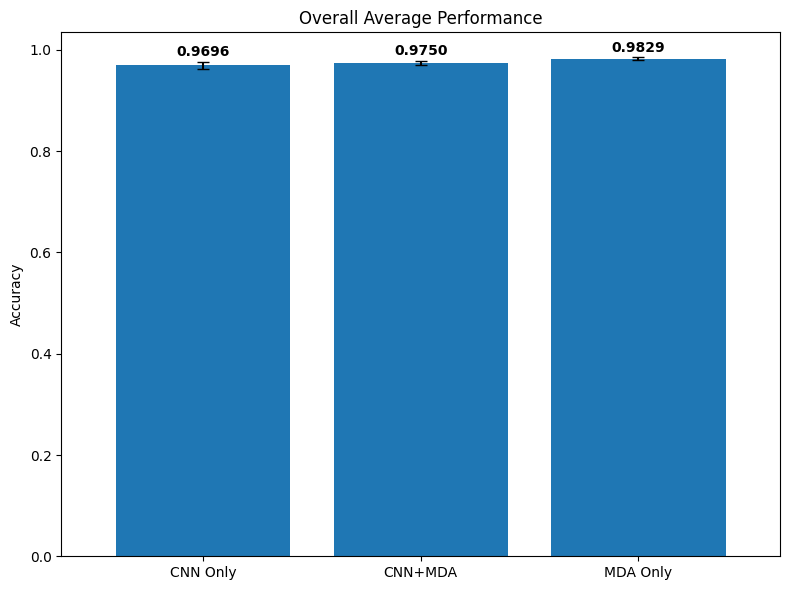

In [19]:
# Get overall means and stds across all conditions
overall_means = df_mean.mean(axis=0)
overall_stds = df_std.mean(axis=0)

print("Overall Average Performance:")
for method in overall_means.index:
    print(f"{method}: {overall_means[method]:.4f} ± {overall_stds[method]:.4f}")
print()

ax = overall_means.plot(kind='bar', figsize=(8, 6), 
                        title='Overall Average Performance',
                        yerr=overall_stds, capsize=4, width=0.8)
plt.ylabel('Accuracy')
plt.xticks(rotation=0)

# values on bars
for i, (method, value) in enumerate(overall_means.items()):
    plt.text(i, value + overall_stds.iloc[i] + 0.005, 
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
conditions = ['speech_clean', 'speech_noise', 'music', 'esc', 'mixed_data']
methods = ['CNN', 'MDA', 'CNN+MDA']

print(f"{'Condition':<15} {'CNN':<10} {'MDA':<10} {'CNN+MDA':<10}")

for condition in conditions:
    row = [condition]
    
    for method in methods:
        method_name = f"{method} training" if method != 'MDA' else 'MDA only training'
        times = [timings.get((condition, fold, f"{method_name} (fold {fold})")) for fold in range(1, k_folds + 1)]
        
        valid_times = [t for t in times if t is not None]
        
        if valid_times:
            avg_time = f"{np.mean(valid_times):.1f}s"
        else:
            avg_time = "N/A"
        
        row.append(avg_time)
    
    print(f"{row[0]:<15} {row[1]:<10} {row[2]:<10} {row[3]:<10}")

Condition       CNN        MDA        CNN+MDA   
speech_clean    47.8s      24.1s      10.0s     
speech_noise    30.8s      19.3s      10.0s     
music           30.7s      22.2s      9.9s      
esc             36.1s      24.1s      10.2s     
mixed_data      33.2s      25.2s      10.3s     


In [ ]:
# Clean up GPU memory
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f"GPU memory cleared")

# References
[1] Y. Panagakis et al., ‘Tensor Methods in Computer Vision and Deep Learning’, Proceedings of the IEEE, vol. 109, no. 5, pp. 863–890, 2021, doi: 10.1109/JPROC.2021.3074329.
[2] D. Salvi et al., ‘POLIPHONE: A Dataset for Smartphone Model Identification From Audio Recordings’, IEEE Access, vol. 13, pp. 37006–37018, 2025, doi: 10.1109/ACCESS.2025.3545152.